In [1]:
# --- Сервісні підключення та команди ---

import pandas as pd
import numpy as np
import os
import re
import openpyxl
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

<h1 style="color: #FF8C00;">КРОК 1.1: Підключення до файлів та змінні шляху</h1>

Використовуємо **універсальний пошук** за ключовими словами (**"single pack"** та **"double pack"**) для коректної ідентифікації підпапок з історичними CSV-звітами. Це робить код стійким до змін у повних назвах папок та універсальним для інших продуктів.

In [2]:
# --- 1. Визначення та Динамічне Витягнення Шляхів (База) ---

# Повний шлях до директорії цільового продукту.
product_dir = '/Users/radyslav/data_analysis/Amazon/prod_perc_dpack/D-Mannose Capsules' 

# Динамічне витягнення назви продукту
product_name = os.path.basename(product_dir)
root_dir = os.path.dirname(product_dir)
costs_file_name = 'Product Cost Info.xlsx'

# Перевірка існування папки продукту
if not os.path.isdir(product_dir):
    raise FileNotFoundError(f"Помилка: Директорія продукту '{product_dir}' не знайдена.")


# --- 2. Корекція та Динамічний Пошук Папок за Ключовими Словами ---

# Отримуємо список усіх елементів у директорії продукту
all_items = os.listdir(product_dir)

# Універсальний пошук папок, що містять ключові слова "single pack" та "double pack"
# next() знаходить перший відповідний елемент, інакше повертає None
single_pack_folder = next((item for item in all_items if "single pack" in item.lower() and os.path.isdir(os.path.join(product_dir, item))), None)
double_pack_folder = next((item for item in all_items if "double pack" in item.lower() and os.path.isdir(os.path.join(product_dir, item))), None)

if not single_pack_folder or not double_pack_folder:
     raise FileNotFoundError("Помилка: Не знайдено підпапок 'Single Pack' або 'Double Pack' у директорії продукту.")

# Створення коректних шляхів
single_pack_dir = os.path.join(product_dir, single_pack_folder)
double_pack_dir = os.path.join(product_dir, double_pack_folder)


# --- 3. Функція для Підрахунку Файлів (Валідація) ---

def count_csv_files(directory):
    """Рахує кількість файлів із розширенням .csv у вказаній директорії."""
    if not os.path.isdir(directory):
        return 0, []
    
    csv_files = [f for f in os.listdir(directory) if f.endswith('.csv')]
    return len(csv_files), csv_files

num_single_files, single_files_list = count_csv_files(single_pack_dir)
num_double_files, double_files_list = count_csv_files(double_pack_dir)


# --- 4. Виведення Результатів та Збереження Змінних ---
print("--- Інформація про Вхідні Дані ---")
print(f"Аналізований Продукт: {product_name}")
print(f"Коренева Директорія (для констант): {root_dir}")
print(f"Шлях Single Pack (визначений): {single_pack_folder}")
print(f"Шлях Double Pack (визначений): {double_pack_folder}")
print(f"Кількість файлів (Single Pack): {num_single_files} CSV-звітів")
print(f"Кількість файлів (Double Pack): {num_double_files} CSV-звітів")

# Зберігаємо шляхи та списки файлів для наступних кроків
pack_dirs = {
    'Single Pack': single_pack_dir,
    'Double Pack': double_pack_dir
}

pack_files = {
    'Single Pack': single_files_list,
    'Double Pack': double_files_list
}

--- Інформація про Вхідні Дані ---
Аналізований Продукт: D-Mannose Capsules
Коренева Директорія (для констант): /Users/radyslav/data_analysis/Amazon/prod_perc_dpack
Шлях Single Pack (визначений): D-Mannose 120 Capsules (Single Pack)
Шлях Double Pack (визначений): D-Mannose 240 Capsules (Double Pack)
Кількість файлів (Single Pack): 6 CSV-звітів
Кількість файлів (Double Pack): 5 CSV-звітів


<h1 style="color: #FF8C00;">КРОК 1.2: Вилучення фінансових констант юніт-економіки</h1>

Впровадження універсальної функції для автоматичного вилучення констант юніт-економіки з файлу `Product Cost Info.xlsx`. Ідентифікація **Single Pack** та **Double Pack** відбувається на основі **кількості одиниць** у назві продукту, що забезпечує стійкість коду до варіацій даних.

In [3]:
# --- 1. Визначення та Перетворення Шляхів ---

# Визначаємо базову назву продукту для фільтрації, видаляючи ' Capsules' для універсальності
# Використовуємо лише 'D-Mannose'
base_product_name = product_name.replace(' Capsules', '').strip() 

# Повний шлях до файлу констант (використовуємо кореневу директорію: root_dir)
costs_file_path = os.path.join(root_dir, costs_file_name)

# --- 2. Універсальна Функція для Вилучення Констант ---

def get_product_unit_economics(file_path, base_name):
    """
    Динамічно зчитує файл собівартості, фільтрує за назвою продукту, 
    визначає Single/Double Pack за кількістю одиниць і надійно очищує фінансові константи.
    """
    try:
        df_costs = pd.read_excel(file_path, header=0)
    except FileNotFoundError:
        print(f"Помилка: Файл собівартості не знайдено за шляхом: {file_path}")
        return {}

    # 1. Нормалізація колонок
    df_costs.columns = df_costs.columns.str.strip().str.lower().str.replace(' ', '_')
    df_costs = df_costs.dropna(subset=['short_product_name']).reset_index(drop=True)

    # 2. Фільтрація за базовою назвою продукту
    df_product_group = df_costs[
        df_costs['short_product_name'].str.contains(base_name, case=False, na=False)
    ].copy()

    if df_product_group.empty:
        print(f"Помилка: Не знайдено даних про витрати для продукту: {base_name}")
        return {}

    # 3. Вилучення кількості одиниць для ідентифікації паків
    # Використовуємо str.extract(r'(\d+)'), щоб знайти перше число в назві
    df_product_group['unit_count'] = df_product_group['short_product_name'].str.extract(r'(\d+)').astype(float)
    df_product_group = df_product_group.dropna(subset=['unit_count'])

    if len(df_product_group) < 2:
        print(f"Помилка: Знайдено лише {len(df_product_group)} варіацій продукту. Потрібно Single та Double Pack.")
        return {}

    # Визначаємо Single Pack (min) та Double Pack (max)
    idx_dp = df_product_group['unit_count'].idxmax()
    idx_sp = df_product_group['unit_count'].idxmin()

    # Створюємо словник з коректним порядком
    results_raw = {
        'Single Pack': df_product_group.loc[idx_sp], 
        'Double Pack': df_product_group.loc[idx_dp]
    }
    
    unit_economics_final = {}
    
    # 4. Надійне Очищення та Зберігання Констант
    for pack_type, data in results_raw.items():
        costs = {}
        
        # COGS та FBA Fee (надійне очищення та перетворення)
        for col in ['cogs', 'fba_fee']:
            raw_value = str(data.get(col, 0)) # Використовуємо .get() з дефолтом 0
            # Видаляємо '$', ','
            cleaned_value = raw_value.strip().replace('$', '').replace(',', '')
            # КЛЮЧОВЕ ВИПРАВЛЕННЯ: примусове перетворення на float
            costs[col] = pd.to_numeric(cleaned_value, errors='coerce') 

        # Ref Fee Rate
        raw_ref_fee = str(data.get('ref_fee', '0%'))
        if '%' in raw_ref_fee:
             ref_fee_rate = pd.to_numeric(raw_ref_fee.strip().replace('%', ''), errors='coerce') / 100
        else:
             numeric_val = pd.to_numeric(raw_ref_fee, errors='coerce')
             # Припускаємо, що значення > 1 є відсотком, який не був позначений %
             ref_fee_rate = numeric_val / 100 if numeric_val > 1 else numeric_val

        costs['ref_fee_rate'] = ref_fee_rate
        costs['asin'] = data['asin'] 
        
        unit_economics_final[pack_type] = costs

    return unit_economics_final

# --- 3. Запуск Функції та Збереження Глобальних Змінних ---

unit_economics = get_product_unit_economics(costs_file_path, base_product_name)

# --- 4. Виведення Результату ---
print("--- Фінансові Константи (unit_economics) ---")
print(f"Константи для {product_name}:")

if unit_economics and len(unit_economics) == 2:
    # Виводимо у потрібному порядку: Single Pack, Double Pack
    for pack in ['Single Pack', 'Double Pack']:
        costs = unit_economics.get(pack, {})
        if not costs: continue # Пропускаємо, якщо пак не знайдено
            
        print(f"\n{pack}:")
        for key, value in costs.items():
            # Забезпечуємо, що value є числом перед форматуванням .2f
            if key == 'ref_fee_rate':
                 print(f"  {key.upper()}: {value:.2%}")
            elif isinstance(value, (int, float, np.number)):
                 print(f"  {key.upper()}: ${value:.2f}")
            else:
                 # Якщо значення все ще не число (NaN або None), виводимо це
                 print(f"  {key.upper()}: {value}")
else:
    print("\n\033[91mКРИТИЧНА ПОМИЛКА: Не вдалося знайти константи для обох паків (Single та Double). Перевірте файл констант!\033[0m")

--- Фінансові Константи (unit_economics) ---
Константи для D-Mannose Capsules:

Single Pack:
  COGS: $4.44
  FBA_FEE: $3.90
  REF_FEE_RATE: 15.00%
  ASIN: B0D322YRQY

Double Pack:
  COGS: $7.38
  FBA_FEE: $4.15
  REF_FEE_RATE: 15.00%
  ASIN: B0DQQCWY6T


<h1 style="color: #FF8C00;">КРОК 1.3: Агрегація даних Single Pack</h1>

Створення універсальної функції для обробки та агрегації **лише** даних **Single Pack**. Дані з CSV-файлів очищуються, сумуються по B2C та B2B, об'єднуються, сортуються за датою, а потім транспонуються для відображення **місяців як колонок** та **показників як рядків**.

In [4]:
# --- Крок 1.3: Завантаження, Агрегація та Трансформація Single Pack (Фінальне Оновлення) ---
# NOTE: unit_economics, pack_dirs, pack_files вважаються визначеними раніше.

# --- 1. Функція для обробки одного CSV-файлу (Single Pack) ---
# ОНОВЛЕНО: видалено 'Page Views'
def process_single_csv(file_path, file_name, current_asin):
    try:
        df = pd.read_csv(file_path, header=0, encoding='utf-8')
    except Exception as e:
        print(f"Помилка зчитування файлу {file_name}: {e}")
        return None, 0

    cols_mapping = {
        'Sessions': ['Sessions - Total', 'Sessions - Total - B2B'],
        'Units Ordered': ['Units Ordered', 'Units Ordered - B2B'],
        'Ordered Product Sales': ['Ordered Product Sales', 'Ordered Product Sales - B2B']
    }
    
    monthly_data = {'ASIN': current_asin}
    rows_processed = len(df)
    
    for new_col, raw_cols in cols_mapping.items():
        temp_df = df[raw_cols].copy()
        
        for col in raw_cols:
            if temp_df[col].dtype == object: 
                temp_df[col] = temp_df[col].astype(str).str.replace(r'[\$,\s]', '', regex=True)
            temp_df[col] = pd.to_numeric(temp_df[col], errors='coerce')
        
        total_sum = temp_df.sum().sum() 
        monthly_data[new_col] = total_sum

    date_match = re.search(r'([A-Za-z]+_\d{4})', file_name)
    monthly_data['Month_Year'] = date_match.group(1) if date_match else "Unknown_Date"

    return pd.DataFrame([monthly_data]), rows_processed


# --- 2. Пакетна Обробка Всіх Файлів Single Pack ---

single_pack_data = []
total_rows_processed = 0
pack_type = 'Single Pack'

asin_sp = unit_economics.get(pack_type, {}).get('asin', 'ASIN_NOT_FOUND')

directory = pack_dirs[pack_type]
file_list = pack_files[pack_type]
    
print(f"Обробка {pack_type} ({len(file_list)} файлів) для ASIN: {asin_sp}...")
    
for file_name in file_list:
    file_path = os.path.join(directory, file_name)
    df_month, rows_count = process_single_csv(file_path, file_name, asin_sp)
    if df_month is not None:
        single_pack_data.append(df_month)
        total_rows_processed += rows_count

df_single_raw = pd.concat(single_pack_data, ignore_index=True)


# --- 3. Трансформація та Сортування ---

# ДОДАНО НАЗАД: Визначення функції create_sort_key
def create_sort_key(month_year_str):
    if '_' in month_year_str:
        date_str = month_year_str.replace('_', ' ')
        try:
            return pd.to_datetime(date_str, format='%B %Y') 
        except ValueError:
            return pd.NaT 
    return pd.NaT

df_single_raw['Date_Sort'] = df_single_raw['Month_Year'].apply(create_sort_key)

df_single_raw = df_single_raw.sort_values(by='Date_Sort').reset_index(drop=True)

# ОНОВЛЕНО: Видалено 'Page Views' зі списку values
df_single_pivot = df_single_raw.pivot_table(
    index='Month_Year', 
    values=['Sessions', 'Units Ordered', 'Ordered Product Sales'],
    aggfunc='sum' 
).T 

month_order = df_single_raw['Month_Year'].unique()
df_single_pivot = df_single_pivot[month_order]

# ОНОВЛЕНО: Видалено 'Page Views' зі списку row_order
row_order = ['Sessions', 'Units Ordered', 'Ordered Product Sales']
df_single_pivot = df_single_pivot.reindex(row_order)

# --- 4. Виведення Результату ---

# Розрахунок загальних сум
total_sessions = df_single_pivot.loc['Sessions'].sum()
# total_page_views видалено
total_units = df_single_pivot.loc['Units Ordered'].sum()
total_sales = df_single_pivot.loc['Ordered Product Sales'].sum()

print("\n--- Додаткова Інформація ---")
print(f"ASIN продукту (Single Pack): {asin_sp}")
print(f"Кількість рядків, оброблених по всім CSV: {total_rows_processed} рядків")
print(f"Загальна сума Sessions: {total_sessions:.2f}") 
# Вивід Page Views видалено
print(f"Загальна сума Units Ordered: {total_units:.2f}") 
print(f"Загальна сума Ordered Product Sales: {total_sales:.2f}")

print("\n--- Звіт Single Pack (Крок 1.3) ---")
print("Таблиця помісячних показників (числа з округленням до 2 цифр):")

# ВИКОРИСТАННЯ STYLER для виводу
df_single_pivot_styled = df_single_pivot.style.format('{:.2f}')
df_single_pivot_styled

Обробка Single Pack (6 файлів) для ASIN: B0D322YRQY...

--- Додаткова Інформація ---
ASIN продукту (Single Pack): B0D322YRQY
Кількість рядків, оброблених по всім CSV: 9 рядків
Загальна сума Sessions: 85526.00
Загальна сума Units Ordered: 31393.00
Загальна сума Ordered Product Sales: 656265.89

--- Звіт Single Pack (Крок 1.3) ---
Таблиця помісячних показників (числа з округленням до 2 цифр):


Month_Year,March_2025,April_2025,May_2025,June_2025,July_2025,August_2025
Sessions,13809.00,11845.00,14038.00,9473.00,16315.00,20046.00
Units Ordered,4650.00,4431.00,5277.00,3839.00,5890.00,7306.00
Ordered Product Sales,96296.42,96231.11,109974.16,83492.16,123644.30,146627.74


<h1 style="color: #FF8C00;">КРОК 1.4: Агрегація даних Double Pack</h1>

На цьому кроці ми виконуємо аналогічні дії, як і для Single Pack, але застосовуємо їх до файлів **Double Pack**. 

Дані очищуються, сумуються по B2C та B2B, об'єднуються, сортуються за датою, а потім транспонуються. Зверніть увагу, що **порядок рядків у фінальній таблиці** відповідає тому, що був використаний у фінальному виводі для Single Pack.

У результаті буде створено **робочий DataFrame `df_double_raw`** для подальших розрахунків та відображено помісячний звіт.

In [5]:
# --- Крок 1.4: Завантаження, Агрегація та Трансформація Double Pack (Фінальна Робоча Версія) ---
# NOTE: Функції process_single_csv та create_sort_key мають бути визначені після Кроку 1.3.

double_pack_data = []
total_rows_processed_dp = 0 
pack_type = 'Double Pack'

asin_dp = unit_economics.get(pack_type, {}).get('asin', 'ASIN_NOT_FOUND')

directory = pack_dirs[pack_type]
file_list = pack_files[pack_type]
    
print(f"Обробка {pack_type} ({len(file_list)} файлів) для ASIN: {asin_dp}...")
    
for file_name in file_list:
    file_path = os.path.join(directory, file_name)
    # Використовуємо оновлену функцію process_single_csv (без Page Views)
    df_month, rows_count = process_single_csv(file_path, file_name, asin_dp) 
    if df_month is not None:
        double_pack_data.append(df_month)
        total_rows_processed_dp += rows_count 

# Створення df_double_raw
df_double_raw = pd.concat(double_pack_data, ignore_index=True)

df_double_raw['Date_Sort'] = df_double_raw['Month_Year'].apply(create_sort_key)

df_double_raw = df_double_raw.sort_values(by='Date_Sort').reset_index(drop=True)

# Створення фінальної таблиці без Page Views
df_double_pivot = df_double_raw.pivot_table(
    index='Month_Year', 
    values=['Sessions', 'Units Ordered', 'Ordered Product Sales'],
    aggfunc='sum' 
).T 

month_order_dp = df_double_raw['Month_Year'].unique()
df_double_pivot = df_double_pivot[month_order_dp]

row_order = ['Sessions', 'Units Ordered', 'Ordered Product Sales']
df_double_pivot = df_double_pivot.reindex(row_order)

# Виведення Результату
total_sessions_dp = df_double_pivot.loc['Sessions'].sum()
total_units_dp = df_double_pivot.loc['Units Ordered'].sum()
total_sales_dp = df_double_pivot.loc['Ordered Product Sales'].sum()

print("\n--- Додаткова Інформація ---")
print(f"ASIN продукту (Double Pack): {asin_dp}")
print(f"Кількість рядків, оброблених по всім CSV: {total_rows_processed_dp} рядків")
print(f"Загальна сума Sessions: {total_sessions_dp:.2f}") 
print(f"Загальна сума Units Ordered: {total_units_dp:.2f}") 
print(f"Загальна сума Ordered Product Sales: {total_sales_dp:.2f}")

print("\n--- Звіт Double Pack (Крок 1.4) ---")
print("Таблиця помісячних показників (числа з округленням до 2 цифр):")

df_double_pivot_styled = df_double_pivot.style.format('{:.2f}')
df_double_pivot_styled

Обробка Double Pack (5 файлів) для ASIN: B0DQQCWY6T...

--- Додаткова Інформація ---
ASIN продукту (Double Pack): B0DQQCWY6T
Кількість рядків, оброблених по всім CSV: 7 рядків
Загальна сума Sessions: 7540.00
Загальна сума Units Ordered: 3716.00
Загальна сума Ordered Product Sales: 125424.40

--- Звіт Double Pack (Крок 1.4) ---
Таблиця помісячних показників (числа з округленням до 2 цифр):


Month_Year,April_2025,May_2025,June_2025,July_2025,August_2025
Sessions,1255.00,1580.00,1109.00,1716.00,1880.00
Units Ordered,570.00,754.00,660.00,881.00,851.00
Ordered Product Sales,18077.60,24126.40,21106.00,30725.80,31388.60


<h1 style="color: #008000;">КРОК 2.1: Розрахунок Net Profit та Profit Return on Cost (P-ROC) для Single Pack</h1>

На цьому ключовому кроці ми використовуємо дані про юніт-економіку (`COGS`, `FBA_FEE`, `REF_FEE_RATE`) для розрахунку двох нових показників:
1.  **Product Costs** (Загальні щомісячні витрати на продукт).
2.  **Net Profit** (Чистий прибуток).

Ми також додаємо показник **Profit Return on Cost (P-ROC)**, який відображає **рентабельність витрат** як відношення `Net Profit` до `Product Costs` для кожного місяця та загалом.

In [6]:
# --- Крок 2.1: Розрахунок Net Profit для Single Pack (Перезапуск) ---

# 1. Отримання констант юніт-економіки для Single Pack
pack_type = 'Single Pack'
cogs = unit_economics[pack_type]['cogs']
fba_fee = unit_economics[pack_type]['fba_fee']
ref_fee_rate = unit_economics[pack_type]['ref_fee_rate']

print(f"Розрахунок Net Profit для {pack_type} (COGS: {cogs:.2f}, FBA: {fba_fee:.2f}, REF_RATE: {ref_fee_rate:.2%})")

# Створюємо копію оновленого робочого DataFrame df_single_raw
# ЗВЕРНІТЬ УВАГУ: df_single_raw тепер не містить Page Views
df_single_kpi = df_single_raw.copy()

# 2. Розрахунок Product Costs та Net Profit
df_single_kpi['Product Costs'] = (
    df_single_kpi['Units Ordered'] * (cogs + fba_fee)
) + (
    df_single_kpi['Ordered Product Sales'] * ref_fee_rate
)

df_single_kpi['Net Profit'] = (
    df_single_kpi['Ordered Product Sales'] - df_single_kpi['Product Costs']
)

# 3. Розрахунок помісячного Profit Return on Cost (P-ROC)
df_single_kpi['Profit Return on Cost'] = (
    df_single_kpi['Net Profit'] / (df_single_kpi['Product Costs'] + 0.0001)
)


# --- 4. Підготовка Таблиці для Виводу (Числові типи) ---

df_single_profit_pivot = df_single_kpi.pivot_table(
    index='Month_Year', 
    values=['Ordered Product Sales', 'Product Costs', 'Net Profit', 'Profit Return on Cost'],
    aggfunc='sum'
).T 

month_order = df_single_kpi['Month_Year'].unique()
df_single_profit_pivot = df_single_profit_pivot[month_order]

row_order_profit = ['Ordered Product Sales', 'Product Costs', 'Net Profit', 'Profit Return on Cost']
df_single_profit_pivot = df_single_profit_pivot.reindex(row_order_profit)


# --- 5. Виведення Результату (ВКЛЮЧАЮЧИ РОЗРАХУНОК СУМАРНИХ ПОКАЗНИКІВ) ---

print("\n--- Звіт Single Pack (Крок 2.1: Net Profit) ---")

# >>> ВАЖЛИВО: Розрахунок сумарних показників за весь період
total_sales_sp = df_single_profit_pivot.loc['Ordered Product Sales'].sum()
total_costs_sp = df_single_profit_pivot.loc['Product Costs'].sum()
total_profit_sp = df_single_profit_pivot.loc['Net Profit'].sum()

# Загальний Profit Return on Cost (P-ROC) 
profit_return_on_cost_sp = (
    total_profit_sp / total_costs_sp
) if total_costs_sp != 0 else 0


print("\n--- Сумарні Показники за Весь Період ---")
print(f"Загальна Ordered Product Sales: {total_sales_sp:.2f}") 
print(f"Загальна Product Costs: {total_costs_sp:.2f}") 
print(f"Загальний Net Profit: {total_profit_sp:.2f}")
print(f"Загальний Profit Return on Cost (P-ROC): {profit_return_on_cost_sp:.2%}") 

print("\nТаблиця помісячного Net Profit (Числові дані з округленням до 2 знаків):")

# ВИКОРИСТАННЯ STYLER ДЛЯ ВИВОДУ
df_single_profit_pivot_styled = df_single_profit_pivot.style.format('{:.2f}')

# ВИВЕДЕННЯ ТАБЛИЦІ
df_single_profit_pivot_styled

Розрахунок Net Profit для Single Pack (COGS: 4.44, FBA: 3.90, REF_RATE: 15.00%)

--- Звіт Single Pack (Крок 2.1: Net Profit) ---

--- Сумарні Показники за Весь Період ---
Загальна Ordered Product Sales: 656265.89
Загальна Product Costs: 360257.50
Загальний Net Profit: 296008.39
Загальний Profit Return on Cost (P-ROC): 82.17%

Таблиця помісячного Net Profit (Числові дані з округленням до 2 знаків):


Month_Year,March_2025,April_2025,May_2025,June_2025,July_2025,August_2025
Ordered Product Sales,96296.42,96231.11,109974.16,83492.16,123644.30,146627.74
Product Costs,53225.46,51389.21,60506.30,44541.08,67669.24,82926.20
Net Profit,43070.96,44841.90,49467.86,38951.08,55975.06,63701.54
Profit Return on Cost,0.81,0.87,0.82,0.87,0.83,0.77


<h1 style="color: #008000;">КРОК 2.2: Розрахунок Net Profit та Profit Return on Cost (P-ROC) для Double Pack</h1>

На цьому кроці ми виконуємо ідентичні розрахунки, як і для Single Pack (Крок 2.1), застосовуючи формули **Product Costs** та **Net Profit** до даних **Double Pack**.

Для відображення даних використовується об'єкт Pandas Styler, що забезпечує округлення до 2 знаків у виводі, зберігаючи при цьому базові дані числовими (`float`) у робочому фреймі.

In [7]:
# --- Крок 2.2: Розрахунок Net Profit для Double Pack ---

# 1. Отримання констант юніт-економіки для Double Pack
pack_type = 'Double Pack'
cogs = unit_economics[pack_type]['cogs']
fba_fee = unit_economics[pack_type]['fba_fee']
ref_fee_rate = unit_economics[pack_type]['ref_fee_rate']

print(f"Розрахунок Net Profit для {pack_type} (COGS: {cogs:.2f}, FBA: {fba_fee:.2f}, REF_RATE: {ref_fee_rate:.2%})")

# Створюємо копію робочого DataFrame Double Pack
df_double_kpi = df_double_raw.copy()

# 2. Розрахунок Product Costs та Net Profit
df_double_kpi['Product Costs'] = (
    df_double_kpi['Units Ordered'] * (cogs + fba_fee)
) + (
    df_double_kpi['Ordered Product Sales'] * ref_fee_rate
)

df_double_kpi['Net Profit'] = (
    df_double_kpi['Ordered Product Sales'] - df_double_kpi['Product Costs']
)

# 3. Розрахунок помісячного Profit Return on Cost (P-ROC)
profit_return_on_cost = df_double_kpi['Net Profit'] / (df_double_kpi['Product Costs'] + 0.0001)
df_double_kpi['Profit Return on Cost'] = profit_return_on_cost


# --- 4. Підготовка Таблиці для Виводу (Числові типи) ---

df_double_profit_pivot = df_double_kpi.pivot_table(
    index='Month_Year', 
    values=['Ordered Product Sales', 'Product Costs', 'Net Profit', 'Profit Return on Cost'],
    aggfunc='sum'
).T 

month_order_dp = df_double_kpi['Month_Year'].unique()
df_double_profit_pivot = df_double_profit_pivot[month_order_dp]

row_order_profit = ['Ordered Product Sales', 'Product Costs', 'Net Profit', 'Profit Return on Cost']
df_double_profit_pivot = df_double_profit_pivot.reindex(row_order_profit)


# --- 5. Виведення Результату ---

print("\n--- Звіт Double Pack (Крок 2.2: Net Profit) ---")

# Розрахунок сумарних показників за весь період
total_sales_dp = df_double_profit_pivot.loc['Ordered Product Sales'].sum()
total_costs_dp = df_double_profit_pivot.loc['Product Costs'].sum()
total_profit_dp = df_double_profit_pivot.loc['Net Profit'].sum()

# Загальний Profit Return on Cost (P-ROC) 
profit_return_on_cost_dp = (
    total_profit_dp / total_costs_dp
) if total_costs_dp != 0 else 0


print("\n--- Сумарні Показники за Весь Період ---")
print(f"Загальна Ordered Product Sales: {total_sales_dp:.2f}") 
print(f"Загальна Product Costs: {total_costs_dp:.2f}") 
print(f"Загальний Net Profit: {total_profit_dp:.2f}")
print(f"Загальний Profit Return on Cost (P-ROC): {profit_return_on_cost_dp:.2%}") 

print("\nТаблиця помісячного Net Profit (Числові дані з округленням до 2 знаків):")

# ВИКОРИСТАННЯ STYLER ДЛЯ ВИВОДУ
df_double_profit_pivot_styled = df_double_profit_pivot.style.format('{:.2f}')

# ВИВЕДЕННЯ ТАБЛИЦІ
df_double_profit_pivot_styled

Розрахунок Net Profit для Double Pack (COGS: 7.38, FBA: 4.15, REF_RATE: 15.00%)

--- Звіт Double Pack (Крок 2.2: Net Profit) ---

--- Сумарні Показники за Весь Період ---
Загальна Ordered Product Sales: 125424.40
Загальна Product Costs: 61659.14
Загальний Net Profit: 63765.26
Загальний Profit Return on Cost (P-ROC): 103.42%

Таблиця помісячного Net Profit (Числові дані з округленням до 2 знаків):


Month_Year,April_2025,May_2025,June_2025,July_2025,August_2025
Ordered Product Sales,18077.60,24126.40,21106.00,30725.80,31388.60
Product Costs,9283.74,12312.58,10775.70,14766.80,14520.32
Net Profit,8793.86,11813.82,10330.30,15959.00,16868.28
Profit Return on Cost,0.95,0.96,0.96,1.08,1.16


<h1 style="color: #008000;">КРОК 2.3.1: Створення фінального робочого датасету для Single Pack</h1>

Цей крок об'єднує дані про продажі та трафік з Кроку 1.3 (`df_single_raw`) із розрахунками чистого прибутку з Кроку 2.1 (`df_single_kpi`).

Результатом є фінальний помісячний робочий датасет (`df_single_final`), який містить всі ключові показники: `Sessions`, `Units Ordered`, `Ordered Product Sales`, `Product Costs` та `Net Profit`.

**Примітка:** Ми використовуємо `df_single_kpi` (створений на Кроці 2.1), оскільки він вже містить всі необхідні розрахунки прибутковості.

In [8]:
# --- Крок 2.3: Створення Фінального Датасету для Single Pack ---

# 1. Визначення необхідних колонок
# Колонка 'Date_Sort' буде використовуватися для сортування, але не для фінального виводу.
final_cols = [
    'Month_Year', 
    'Sessions', 
    'Units Ordered', 
    'Ordered Product Sales', 
    'Product Costs', 
    'Net Profit',
    'Date_Sort' # Потрібна для сортування
]

# 2. Об'єднання та очищення (ми беремо df_single_kpi, оскільки він містить ВСЕ необхідне)
# df_single_kpi був створений на Кроці 2.1 і вже містить дані з df_single_raw
df_single_final = df_single_kpi[final_cols].copy()

# 3. Трансформація: Створення Pivot-таблиці
# Нам потрібен помісячний звіт у форматі: Місяць (колонки) та Показники (рядки)
df_single_final_pivot = df_single_final.pivot_table(
    index='Month_Year', 
    values=['Sessions', 'Units Ordered', 'Ordered Product Sales', 'Product Costs', 'Net Profit'],
    aggfunc='sum' 
).T 

# 4. Сортування та реіндексація

# Забезпечуємо правильний порядок колонок (місяців)
month_order = df_single_final['Month_Year'].unique()
df_single_final_pivot = df_single_final_pivot[month_order]

# Встановлюємо потрібний порядок рядків
row_order_final = ['Sessions', 'Units Ordered', 'Ordered Product Sales', 'Product Costs', 'Net Profit']
df_single_final_pivot = df_single_final_pivot.reindex(row_order_final)


# --- 5. Виведення Результату ---

print("\n--- Звіт Single Pack (Крок 2.3: Фінальний Датасет) ---")
print("Зведена таблиця основних показників (числа з округленням до 2 знаків):")

# ВИКОРИСТАННЯ STYLER для виводу
df_single_final_pivot_styled = df_single_final_pivot.style.format('{:.2f}')

# ВИВЕДЕННЯ ТАБЛИЦІ
df_single_final_pivot_styled


--- Звіт Single Pack (Крок 2.3: Фінальний Датасет) ---
Зведена таблиця основних показників (числа з округленням до 2 знаків):


Month_Year,March_2025,April_2025,May_2025,June_2025,July_2025,August_2025
Sessions,13809.00,11845.00,14038.00,9473.00,16315.00,20046.00
Units Ordered,4650.00,4431.00,5277.00,3839.00,5890.00,7306.00
Ordered Product Sales,96296.42,96231.11,109974.16,83492.16,123644.30,146627.74
Product Costs,53225.46,51389.21,60506.30,44541.08,67669.24,82926.20
Net Profit,43070.96,44841.90,49467.86,38951.08,55975.06,63701.54


<h1 style="color: #008000;">КРОК 2.3.2: Статистичний Аналіз та IQR для Single Pack</h1>

Цей крок проводить **описовий статистичний аналіз** основних показників продажів $\text{Single Pack}$ ($\text{Sessions}$, $\text{Units Ordered}$, $\text{Ordered Product Sales}$, $\text{Product Costs}$, $\text{Net Profit}$).

### 🎯 Мета Аналізу

Оцінити **розмах даних** та **виявити викиди ($\text{Outliers}$)**, використовуючи **Міжквартильний Діапазон ($\text{IQR}$)**. Це є критично важливим для підтвердження надійності даних перед побудовою регресійних моделей.

### 🛠️ Структура Результату

| Метрика | Опис |
| :--- | :--- |
| **Count** | Кількість точок даних (місяців). |
| **Mean / Median** | Середнє значення та медіана. |
| **Std Dev** | Стандартне відхилення (міра варіативності). |
| **IQR** | Міжквартильний діапазон ($\text{Q3} - \text{Q1}$). |
| **Upper/Lower Limit** | Межі, за якими значення вважаються викидами ($\text{Q3} \pm 1.5 \times \text{IQR}$). |

---

### 💡 Ключові Висновки Аналізу (Single Pack)

На основі табличного та візуального аналізу зроблено такі висновки:

1.  **Чистота Даних:** Для **всіх 5 ключових показників** результат **$\text{Outliers Detected} = \text{NO}$**. Це підтверджує, що в 6 місячних точках даних **немає статистично значущих викидів** (аномалій), які б виходили за межі $\text{IQR} \pm 1.5$.
2.  **Варіативність:** Показники $\text{Sessions}$ та $\text{Net Profit}$ демонструють помірну варіативність ($\text{Std Dev}$ близько $18-20\%$ від $\text{Mean}$), що є очікуваним для помісячних бізнес-даних.
3.  **Готовність до Моделювання:** Оскільки дані є **чистими від викидів**, вони вважаються надійними та можуть бути безпосередньо використані для регресійного аналізу.


--- Звіт Крок 2.3.2: Статистичний Аналіз Single Pack ---


,Count,Min,Max,Mean,Median (Q2),Std Dev,Q1 (25%),Q3 (75%),IQR,Lower Limit,Upper Limit,Outliers Detected
Sessions,6,9473.00,20046.00,14254.33,13923.50,3652.42,12336.00,15745.75,3409.75,7221.38,20860.38,NO
Units Ordered,6,3839.00,7306.00,5232.17,4963.50,1237.52,4485.75,5736.75,1251.00,2609.25,7613.25,NO
Ordered Product Sales,6,83492.16,146627.74,109377.65,103135.29,22827.49,96247.44,120226.76,23979.33,60278.45,156195.76,NO
Product Costs,6,44541.08,82926.20,60042.92,56865.88,13738.21,51848.27,65878.51,14030.24,30802.91,86923.87,NO
Net Profit,6,38951.08,63701.54,49334.73,47154.88,9140.65,43513.69,54348.26,10834.56,27261.85,70600.10,NO



--- Скринькові Діаграми (Box Plots) для Single Pack ---


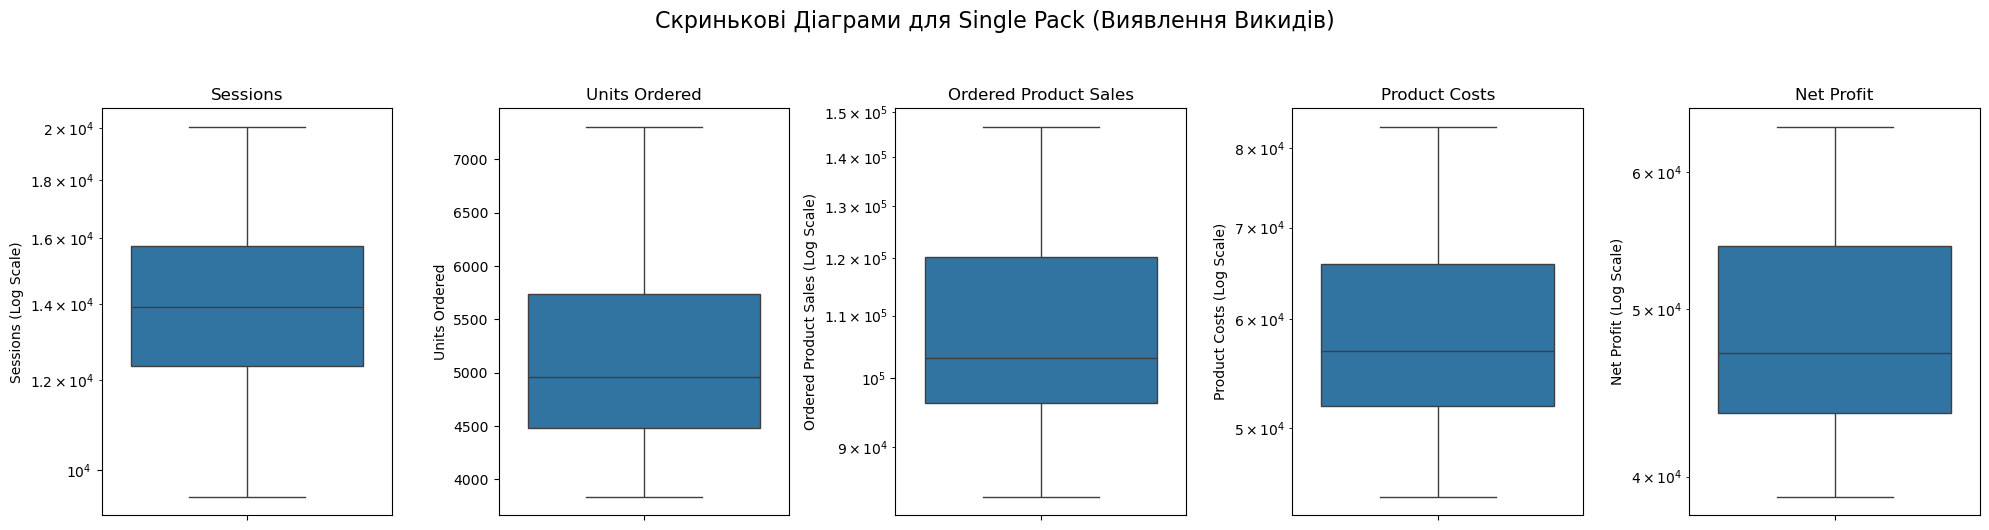


--- Аналіз Single Pack завершено. ---


In [9]:
# --- 1. ПІДГОТОВКА ДАНИХ (df_sp_analysis) ---

# df_single_final має формат: [Month_Year, Sessions, Units Ordered, ...]
# Для аналізу нам потрібні лише числові колонки.
df_sp_analysis = df_single_final.drop(columns=['Month_Year', 'Date_Sort']).copy()
metrics_to_analyze = df_sp_analysis.columns.tolist()

# Функція для розрахунку IQR та меж викидів
def calculate_iqr_stats(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    
    # Визначення, чи є викиди
    outliers_present = (series < lower_limit).any() or (series > upper_limit).any()
    
    return pd.Series({
        'Count': series.count(),
        'Min': series.min(),
        'Max': series.max(),
        'Mean': series.mean(),
        'Median (Q2)': series.median(),
        'Std Dev': series.std(),
        'Q1 (25%)': q1,
        'Q3 (75%)': q3,
        'IQR': iqr,
        'Lower Limit': lower_limit,
        'Upper Limit': upper_limit,
        'Outliers Detected': 'YES' if outliers_present else 'NO'
    })

# Застосовуємо функцію до кожного стовпця (показника)
df_sp_stats = df_sp_analysis[metrics_to_analyze].apply(calculate_iqr_stats).T


# --- 2. ВИВЕДЕННЯ ТАБЛИЦІ ЗІ СТИЛЕМ ---

print("\n--- Звіт Крок 2.3.2: Статистичний Аналіз Single Pack ---")

# Визначаємо порядок стовпців для виводу
stat_order = [
    'Count', 'Min', 'Max', 'Mean', 'Median (Q2)', 'Std Dev', 
    'Q1 (25%)', 'Q3 (75%)', 'IQR', 'Lower Limit', 'Upper Limit', 'Outliers Detected'
]
df_sp_stats = df_sp_stats[stat_order]

# Стилізуємо таблицю
def style_sp_stats(df):
    
    df_styled = df.copy()
    
    # Безпечно виділяємо Outliers Detected перед конвертацією
    outliers_series = df_styled['Outliers Detected'].copy()
    df_styled = df_styled.drop(columns=['Outliers Detected'])
    
    # Конвертуємо всі числові колонки в float і округлюємо
    for col in df_styled.columns:
        if col != 'Count':
             df_styled[col] = pd.to_numeric(df_styled[col], errors='coerce').round(2)

    # Конвертуємо Count в int
    df_styled['Count'] = df_styled['Count'].astype(int)
    
    # Додаємо Outliers Detected назад
    df_styled['Outliers Detected'] = outliers_series
    
    # Форматування та колір
    style_obj = df_styled.style.format({
        col: '{:d}' if col == 'Count' else '{:.2f}'
        for col in df_styled.columns if col != 'Outliers Detected'
    })

    # Застосування кольору для виявлення викидів (використовуємо axis=1)
    style_obj = style_obj.apply(
        lambda x: ['background-color: lightcoral' if x.loc['Outliers Detected'] == 'YES' else '' for _ in x], 
        axis=1
    )
    
    return style_obj

display(style_sp_stats(df_sp_stats))


# --- 3. ВІЗУАЛІЗАЦІЯ (BOX PLOTS) ---

print("\n--- Скринькові Діаграми (Box Plots) для Single Pack ---")

fig, axes = plt.subplots(nrows=1, ncols=len(metrics_to_analyze), figsize=(20, 5))
fig.suptitle('Скринькові Діаграми для Single Pack (Виявлення Викидів)', fontsize=16, y=1.05)

for i, metric in enumerate(metrics_to_analyze):
    sns.boxplot(
        y=df_sp_analysis[metric], 
        ax=axes[i], 
        color='#1f77b4',
        orient='v'
    )
    axes[i].set_title(metric, fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    
    # Використання логарифмічної шкали для кращої візуалізації
    if metric in ['Sessions', 'Ordered Product Sales', 'Product Costs', 'Net Profit']:
        axes[i].set_yscale('log')
        axes[i].set_ylabel(f'{metric} (Log Scale)')
    else:
        axes[i].set_ylabel(metric)

plt.tight_layout()
plt.show()

print("\n--- Аналіз Single Pack завершено. ---")

<h1 style="color: #008000;">КРОК 2.4.1: Створення фінального робочого датасету для Double Pack</h1>

Цей крок ідентичний Кроку 2.3, але застосовується до продукту Double Pack. Ми об'єднуємо дані про продажі та трафік (з Кроку 1.4) із розрахунками чистого прибутку (з Кроку 2.2).

Результатом є фінальний помісячний робочий датасет (`df_double_final`), що містить ключові показники: `Sessions`, `Units Ordered`, `Ordered Product Sales`, `Product Costs` та `Net Profit`.

In [10]:
# --- Крок 2.4: Створення Фінального Датасету для Double Pack ---

# 1. Визначення необхідних колонок
# df_double_kpi був створений на Кроці 2.2 і містить всі необхідні розрахунки.
final_cols_dp = [
    'Month_Year', 
    'Sessions', 
    'Units Ordered', 
    'Ordered Product Sales', 
    'Product Costs', 
    'Net Profit',
    'Date_Sort' # Потрібна для сортування
]

# 2. Об'єднання та очищення (ми беремо df_double_kpi)
# Припускаємо, що df_double_kpi був визначений на Кроці 2.2
df_double_final = df_double_kpi[final_cols_dp].copy()

# 3. Трансформація: Створення Pivot-таблиці
df_double_final_pivot = df_double_final.pivot_table(
    index='Month_Year', 
    values=['Sessions', 'Units Ordered', 'Ordered Product Sales', 'Product Costs', 'Net Profit'],
    aggfunc='sum' 
).T 

# 4. Сортування та реіндексація

# Забезпечуємо правильний порядок колонок (місяців)
month_order_dp = df_double_final['Month_Year'].unique()
df_double_final_pivot = df_double_final_pivot[month_order_dp]

# Встановлюємо потрібний порядок рядків
row_order_final = ['Sessions', 'Units Ordered', 'Ordered Product Sales', 'Product Costs', 'Net Profit']
df_double_final_pivot = df_double_final_pivot.reindex(row_order_final)


# --- 5. Виведення Результату ---

print("\n--- Звіт Double Pack (Крок 2.4: Фінальний Датасет) ---")
print("Зведена таблиця основних показників (числа з округленням до 2 знаків):")

# ВИКОРИСТАННЯ STYLER для виводу
df_double_final_pivot_styled = df_double_final_pivot.style.format('{:.2f}')

# ВИВЕДЕННЯ ТАБЛИЦІ
df_double_final_pivot_styled


--- Звіт Double Pack (Крок 2.4: Фінальний Датасет) ---
Зведена таблиця основних показників (числа з округленням до 2 знаків):


Month_Year,April_2025,May_2025,June_2025,July_2025,August_2025
Sessions,1255.00,1580.00,1109.00,1716.00,1880.00
Units Ordered,570.00,754.00,660.00,881.00,851.00
Ordered Product Sales,18077.60,24126.40,21106.00,30725.80,31388.60
Product Costs,9283.74,12312.58,10775.70,14766.80,14520.32
Net Profit,8793.86,11813.82,10330.30,15959.00,16868.28


<h1 style="color: #008000;">КРОК 2.4.2: Статистичний Аналіз та IQR для Double Pack</h1>

Цей крок проводить **описовий статистичний аналіз** основних показників продажів $\text{Double Pack}$ ($\text{Sessions}$, $\text{Units Ordered}$, $\text{Ordered Product Sales}$, $\text{Product Costs}$, $\text{Net Profit}$).

### 🎯 Мета Аналізу

Виявлення викидів ($\text{Outliers}$) за допомогою **Міжквартильного Діапазону ($\text{IQR}$)**, щоб гарантувати надійність даних $\text{Double Pack}$ перед подальшим регресійним моделюванням.

### 🛠️ Структура Результату

| Метрика | Опис |
| :--- | :--- |
| **Count** | Кількість точок даних (місяців). |
| **Mean / Median** | Центральна тенденція. |
| **Std Dev** | Стандартне відхилення (міра варіативності). |
| **IQR** | Міжквартильний діапазон ($\text{Q3} - \text{Q1}$). |
| **Upper/Lower Limit** | Межі, за якими значення вважаються викидами ($\text{Q3} \pm 1.5 \times \text{IQR}$). |

---

### 💡 Ключові Висновки Аналізу (Double Pack)

1.  **Чистота Даних:** Для **всіх 5 ключових показників** результат **$\text{Outliers Detected} = \text{NO}$**. **Аналіз підтвердив, що дані Double Pack також є чистими від викидів.**
2.  **Варіативність:** Показники $\text{Double Pack}$ є значно нижчими за $\text{Single Pack}$ (що очікувано, оскільки це апсейл), але їхня внутрішня варіативність є керованою.
3.  **Готовність до Моделювання:** **Це означає, що обидва продуктові набори мають надійні часові ряди для використання в регресійних моделях.**


--- Звіт Крок 2.4.2: Статистичний Аналіз Double Pack ---


,Count,Min,Max,Mean,Median (Q2),Std Dev,Q1 (25%),Q3 (75%),IQR,Lower Limit,Upper Limit,Outliers Detected
Sessions,5,1109.00,1880.00,1508.00,1580.00,320.17,1255.00,1716.00,461.00,563.50,2407.50,NO
Units Ordered,5,570.00,881.00,743.20,754.00,130.04,660.00,851.00,191.00,373.50,1137.50,NO
Ordered Product Sales,5,18077.60,31388.60,25084.88,24126.40,5861.08,21106.00,30725.80,9619.80,6676.30,45155.50,NO
Product Costs,5,9283.74,14766.80,12331.83,12312.58,2368.09,10775.70,14520.32,3744.62,5158.77,20137.25,NO
Net Profit,5,8793.86,16868.28,12753.05,11813.82,3522.79,10330.30,15959.00,5628.70,1887.25,24402.05,NO



--- Скринькові Діаграми (Box Plots) для Double Pack ---


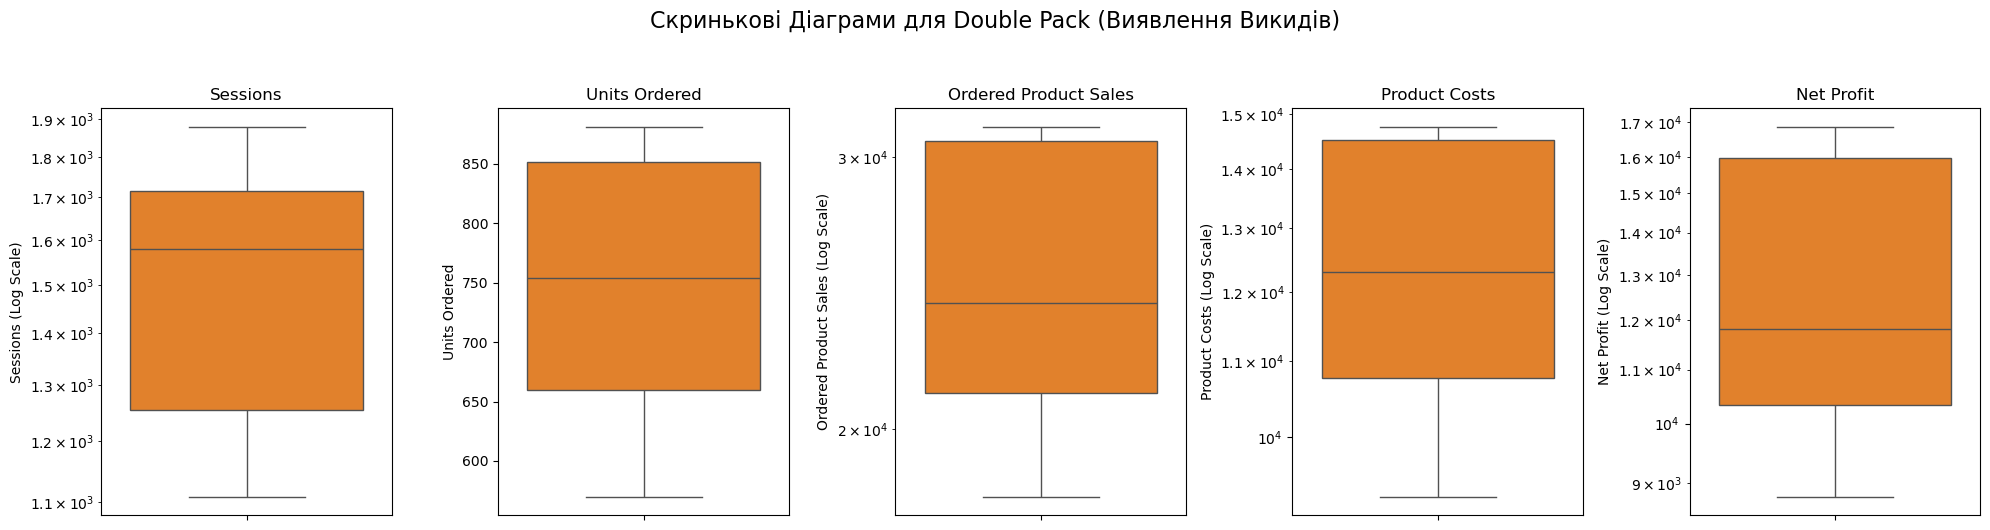


--- Аналіз Double Pack завершено. ---


In [11]:
# --- 1. ПІДГОТОВКА ДАНИХ (df_dp_analysis) ---

# NOTE: Припускаємо, що df_double_final визначений раніше.
# df_double_final має формат: [Month_Year, Sessions, Units Ordered, ...]
# Для аналізу потрібні лише числові колонки.
df_dp_analysis = df_double_final.drop(columns=['Month_Year', 'Date_Sort'], errors='ignore').copy()
metrics_to_analyze = df_dp_analysis.columns.tolist()

# Функція для розрахунку IQR та меж викидів (перевірена)
def calculate_iqr_stats(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr
    
    # Визначення, чи є викиди
    outliers_present = (series < lower_limit).any() or (series > upper_limit).any()
    
    return pd.Series({
        'Count': series.count(),
        'Min': series.min(),
        'Max': series.max(),
        'Mean': series.mean(),
        'Median (Q2)': series.median(),
        'Std Dev': series.std(),
        'Q1 (25%)': q1,
        'Q3 (75%)': q3,
        'IQR': iqr,
        'Lower Limit': lower_limit,
        'Upper Limit': upper_limit,
        'Outliers Detected': 'YES' if outliers_present else 'NO'
    })

# Застосовуємо функцію до кожного стовпця (показника)
df_dp_stats = df_dp_analysis[metrics_to_analyze].apply(calculate_iqr_stats).T


# --- 2. ВИВЕДЕННЯ ТАБЛИЦІ ЗІ СТИЛЕМ ---

print("\n--- Звіт Крок 2.4.2: Статистичний Аналіз Double Pack ---")

# Визначаємо порядок стовпців для виводу
stat_order = [
    'Count', 'Min', 'Max', 'Mean', 'Median (Q2)', 'Std Dev', 
    'Q1 (25%)', 'Q3 (75%)', 'IQR', 'Lower Limit', 'Upper Limit', 'Outliers Detected'
]
df_dp_stats = df_dp_stats[stat_order]

# Стилізуємо таблицю (перевірена функція)
def style_dp_stats(df):
    
    df_styled = df.copy()
    
    # Безпечно виділяємо Outliers Detected
    outliers_series = df_styled['Outliers Detected'].copy()
    df_styled = df_styled.drop(columns=['Outliers Detected'])
    
    # Конвертуємо всі числові колонки в float і округлюємо
    for col in df_styled.columns:
        if col != 'Count':
             df_styled[col] = pd.to_numeric(df_styled[col], errors='coerce').round(2)

    # Конвертуємо Count в int
    df_styled['Count'] = df_styled['Count'].astype(int)
    
    # Додаємо Outliers Detected назад
    df_styled['Outliers Detected'] = outliers_series
    
    # Форматування та колір
    style_obj = df_styled.style.format({
        col: '{:d}' if col == 'Count' else '{:.2f}'
        for col in df_styled.columns if col != 'Outliers Detected'
    })

    # Застосування кольору для виявлення викидів (використовуємо axis=1)
    style_obj = style_obj.apply(
        lambda x: ['background-color: lightcoral' if x.loc['Outliers Detected'] == 'YES' else '' for _ in x], 
        axis=1
    )
    
    return style_obj

display(style_dp_stats(df_dp_stats))


# --- 3. ВІЗУАЛІЗАЦІЯ (BOX PLOTS) ---

print("\n--- Скринькові Діаграми (Box Plots) для Double Pack ---")

fig, axes = plt.subplots(nrows=1, ncols=len(metrics_to_analyze), figsize=(20, 5))
fig.suptitle('Скринькові Діаграми для Double Pack (Виявлення Викидів)', fontsize=16, y=1.05)

for i, metric in enumerate(metrics_to_analyze):
    sns.boxplot(
        y=df_dp_analysis[metric], 
        ax=axes[i], 
        color='#ff7f0e', # Помаранчевий для Double Pack
        orient='v'
    )
    axes[i].set_title(metric, fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    
    # Використання логарифмічної шкали для кращої візуалізації
    if metric in ['Sessions', 'Ordered Product Sales', 'Product Costs', 'Net Profit']:
        axes[i].set_yscale('log')
        axes[i].set_ylabel(f'{metric} (Log Scale)')
    else:
        axes[i].set_ylabel(metric)

plt.tight_layout()
plt.show()

print("\n--- Аналіз Double Pack завершено. ---")

<h1 style="color: #008000;">❗️КРОК 2.5: Створення єдиного порівняльного датасету з фільтрацією за спільними місяцями</h1>

На цьому кроці ми створюємо єдину зведену таблицю (`df_comparison_pivot`), яка містить:
1.  **Лише спільні періоди (місяці)** для Single Pack та Double Pack.
2.  **Мультиіндекс** у колонках для зручного порівняння показників за продуктами в рамках одного місяця.

Цей датасет стане основою для подальшого аналізу ефективності.

In [12]:
# --- Крок 2.5: Створення Порівняльного Датасету (ФІНАЛЬНО ВИПРАВЛЕНО) ---

# NOTE: process_single_csv, create_sort_key, df_single_final, df_double_final мають бути визначені раніше.
from IPython.display import display # Для гарантованого виводу в Jupyter

# 1. Знаходимо спільні місяці
months_single = set(df_single_final['Month_Year'].unique())
months_double = set(df_double_final['Month_Year'].unique())

# Сортування спільних місяців за допомогою ключової функції
common_months = sorted(list(months_single.intersection(months_double)), key=create_sort_key)
pack_type_order = ['Single Pack', 'Double Pack'] # Визначаємо порядок тут

if not common_months:
    print("❌ Помилка: Спільних місяців для порівняння не знайдено.")
    df_comparison_pivot = pd.DataFrame() 
else:
    print(f"✅ Знайдено спільні місяці для порівняння: {', '.join(common_months)}")

    # 2. Підготовка вертикальних фреймів та Об'єднання
    df_single_combined = df_single_final.assign(Pack_Type='Single Pack')
    df_double_combined = df_double_final.assign(Pack_Type='Double Pack')
    df_combined = pd.concat([df_single_combined, df_double_combined], ignore_index=True)
    df_combined_filtered = df_combined[df_combined['Month_Year'].isin(common_months)].copy()

    # 3. Встановлення категоріального типу та створення Pivot
    df_combined_filtered['Pack_Type'] = pd.Categorical(
        df_combined_filtered['Pack_Type'], 
        categories=pack_type_order, 
        ordered=True
    )

    comparison_values = ['Sessions', 'Units Ordered', 'Ordered Product Sales', 'Product Costs', 'Net Profit']

    df_for_pivot = df_combined_filtered[['Month_Year', 'Pack_Type'] + comparison_values].melt(
        id_vars=['Month_Year', 'Pack_Type'],
        value_vars=comparison_values,
        var_name='Metric',
        value_name='Value'
    )
    
    # --- ВИПРАВЛЕННЯ ЗСУВУ ДАНИХ: Додаємо явне сортування df_for_pivot ---
    df_for_pivot['Date_Sort'] = df_for_pivot['Month_Year'].apply(create_sort_key)
    
    df_for_pivot = df_for_pivot.sort_values(
        by=['Date_Sort', 'Pack_Type']
    ).drop(columns=['Date_Sort'])
    # -----------------------------------------------------------

    df_comparison_pivot = df_for_pivot.pivot_table(
        index='Metric', 
        columns=['Month_Year', 'Pack_Type'], 
        values='Value',
        aggfunc='sum',
        observed=False 
    )

    # 4. Сортування Колонок 
    sorted_cols = []
    for month in common_months:
        for pack in pack_type_order:
            sorted_cols.append((month, pack))

    df_comparison_pivot = df_comparison_pivot[sorted_cols]
    df_comparison_pivot.columns.names = ['Month_Year', 'Pack_Type']
    
    # Сортування Рядків
    df_comparison_pivot = df_comparison_pivot.reindex(comparison_values)


# --- 5. Виведення Результату ---

if not df_comparison_pivot.empty:
    print("\n--- Звіт Single vs Double Pack (Крок 2.6: Порівняльна Зведена Таблиця) ---")
    print(f"Таблиця містить лише спільні місяці: {', '.join(common_months)}")
    print("Зведена таблиця основних показників (числа з округленням до 2 знаків):")

    # --- ВИПРАВЛЕННЯ ФОРМАТУВАННЯ: Прибрано кому (,) ---
    df_comparison_pivot_styled = df_comparison_pivot.style.format('{:.2f}') 

    display(df_comparison_pivot_styled)

✅ Знайдено спільні місяці для порівняння: April_2025, May_2025, June_2025, July_2025, August_2025

--- Звіт Single vs Double Pack (Крок 2.6: Порівняльна Зведена Таблиця) ---
Таблиця містить лише спільні місяці: April_2025, May_2025, June_2025, July_2025, August_2025
Зведена таблиця основних показників (числа з округленням до 2 знаків):


<h1 style="color: #008000;">КРОК 2.6: Консолідований експорт фінальних датасетів у Excel</h1>

Цей крок об'єднує всі експорти Excel:
1.  **Single Pack Final KPI** (`df_single_final_pivot`).
2.  **Double Pack Final KPI** (`df_double_final_pivot`).
3.  **Порівняльна Зведена Таблиця** (`df_comparison_pivot`).

Ми експортуємо дані у два окремі файли Excel, додаючи третій, ключовий порівняльний датасет.

In [13]:
'''
# --- Крок 2.7: Консолідований Експорт Фінальних Датасетів у Excel ---
# Припускаємо, що root_dir, product_name, df_single_final_pivot, 
# df_double_final_pivot та df_comparison_pivot визначені.

# 1. Експорт Single Pack Final KPI та Double Pack Final KPI (Крок 2.5 - Single File)

# Визначаємо шлях до файлу Excel для Single Pack
excel_output_path_sp = os.path.join(
    root_dir, 
    product_name, 
    f"{product_name}_Single_Pack_Final_KPI.xlsx"
)

try:
    # Експортуємо DataFrame df_single_final_pivot
    df_single_final_pivot.to_excel(
        excel_output_path_sp, 
        sheet_name='Single_Pack_KPI_Summary', 
        index=True  # Зберігаємо показники як індекс
    )

    print(f"✅ 1/3: Фінальний датасет Single Pack успішно експортовано до:")
    print(excel_output_path_sp)

except Exception as e:
    print(f"❌ Помилка експорту Single Pack: {e}")


# 2. Експорт Double Pack Final KPI (Крок 2.5 - Double File)

# Визначаємо шлях до файлу Excel для Double Pack
excel_output_path_dp = os.path.join(
    root_dir, 
    product_name, 
    f"{product_name}_Double_Pack_Final_KPI.xlsx"
)

try:
    # Експортуємо DataFrame df_double_final_pivot
    df_double_final_pivot.to_excel(
        excel_output_path_dp, 
        sheet_name='Double_Pack_KPI_Summary', 
        index=True 
    )

    print(f"✅ 2/3: Фінальний датасет Double Pack успішно експортовано до:")
    print(excel_output_path_dp)

except Exception as e:
    print(f"❌ Помилка експорту Double Pack: {e}")


# 3. Експорт Порівняльної Зведеної Таблиці (Крок 2.6)

# Визначаємо шлях до файлу Excel для порівняльної таблиці
excel_output_path_comp = os.path.join(
    root_dir, 
    product_name, 
    f"{product_name}_Comparison_KPI_Summary.xlsx"
)

try:
    # Експортуємо DataFrame df_comparison_pivot
    # ВАЖЛИВО: Оскільки це MultiIndex, експортуємо його напряму
    df_comparison_pivot.to_excel(
        excel_output_path_comp, 
        sheet_name='Single_vs_Double_Comparison', 
        index=True 
    )

    print(f"✅ 3/3: Порівняльна зведена таблиця успішно експортовано до:")
    print(excel_output_path_comp)

except Exception as e:
    print(f"❌ Помилка експорту Comparison Summary: {e}")
'''

'\n# --- Крок 2.7: Консолідований Експорт Фінальних Датасетів у Excel ---\n# Припускаємо, що root_dir, product_name, df_single_final_pivot, \n# df_double_final_pivot та df_comparison_pivot визначені.\n\n# 1. Експорт Single Pack Final KPI та Double Pack Final KPI (Крок 2.5 - Single File)\n\n# Визначаємо шлях до файлу Excel для Single Pack\nexcel_output_path_sp = os.path.join(\n    root_dir, \n    product_name, \n    f"{product_name}_Single_Pack_Final_KPI.xlsx"\n)\n\ntry:\n    # Експортуємо DataFrame df_single_final_pivot\n    df_single_final_pivot.to_excel(\n        excel_output_path_sp, \n        sheet_name=\'Single_Pack_KPI_Summary\', \n        index=True  # Зберігаємо показники як індекс\n    )\n\n    print(f"✅ 1/3: Фінальний датасет Single Pack успішно експортовано до:")\n    print(excel_output_path_sp)\n\nexcept Exception as e:\n    print(f"❌ Помилка експорту Single Pack: {e}")\n\n\n# 2. Експорт Double Pack Final KPI (Крок 2.5 - Double File)\n\n# Визначаємо шлях до файлу Excel для 

<h1 style="color: #008000;">📈КРОК 2.7: Візуальний аналіз динаміки Single Pack та Double Pack</h1>

Цей крок забезпечує візуальний порівняльний аналіз динаміки ключових показників (`Sessions`, `Units Ordered`, `Net Profit` тощо) для Single Pack та Double Pack за спільні місяці.

Графіки згруповані попарно (Single Pack та Double Pack) для зручності візуального порівняння.
**Примітка:** Для візуалізації використовується бібліотека `matplotlib.pyplot`.

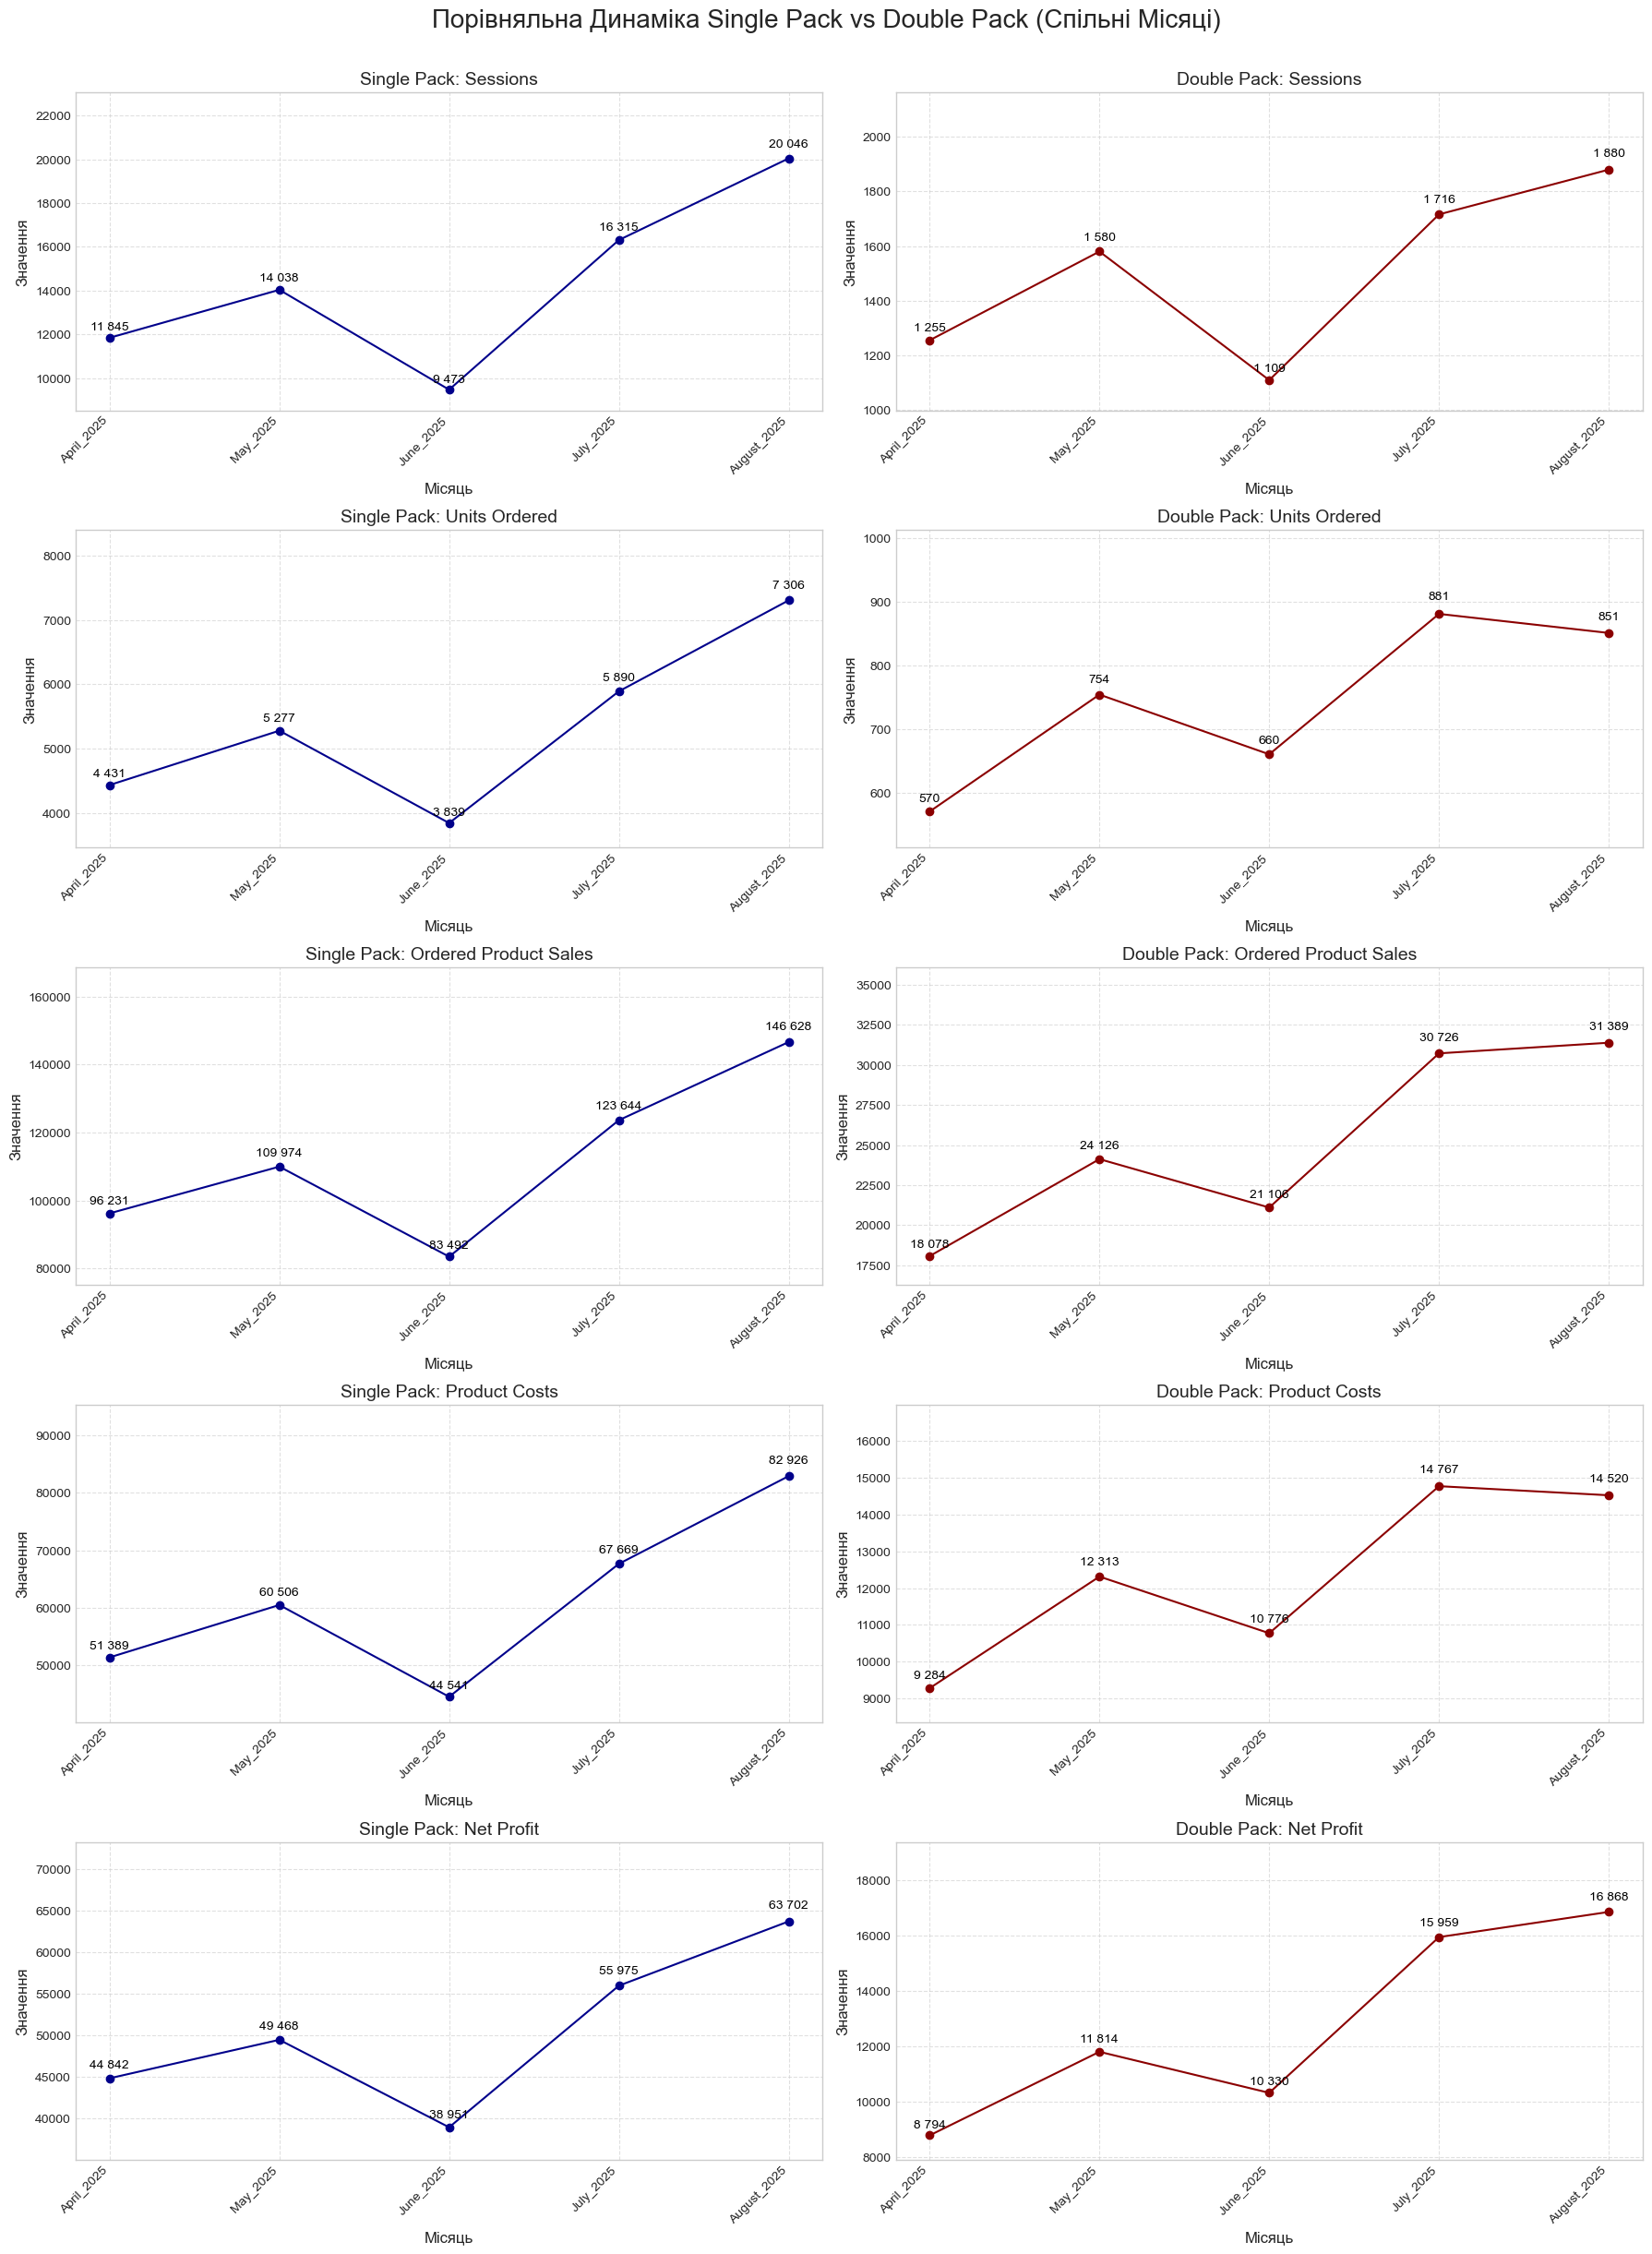


--- Візуальний аналіз динаміки з підписами завершено. ---


In [14]:
# Встановлення стилю для кращого відображення
plt.style.use('seaborn-v0_8-whitegrid') 

# --- КРОК 2.7: Візуальний Аналіз Динаміки (Фінальна Версія) ---

# Припускаємо, що df_comparison_pivot визначений
df_plot = df_comparison_pivot.copy()

metrics_to_plot = df_plot.index.tolist()
num_metrics = len(metrics_to_plot)

# Створення єдиної фігури: 5 рядків, 2 колонки
# Збільшуємо загальний розмір, щоб розмістити підписи
fig, axes = plt.subplots(num_metrics, 2, figsize=(18, 5 * num_metrics)) 
fig.suptitle('Порівняльна Динаміка Single Pack vs Double Pack (Спільні Місяці)', fontsize=20, y=1.005)

pack_types = ['Single Pack', 'Double Pack']

for i, metric in enumerate(metrics_to_plot):
    
    metric_data = df_plot.loc[metric]
    
    for j, pack_type in enumerate(pack_types):
        
        ax = axes[i, j]
        data = metric_data.loc[:, pack_type]
        
        # Визначаємо колір
        color = 'darkblue' if pack_type == 'Single Pack' else 'darkred'
        
        # 1. Побудова лінійного графіка
        data.plot(ax=ax, marker='o', linestyle='-', color=color)
        
        # 2. ДОДАВАННЯ ЧИСЛОВИХ ПІДПИСІВ (Ключова Зміна)
        x_coords = range(len(data.index)) # Використовуємо індекси для позиції X
        y_values = data.values
        
        for k, y in enumerate(y_values):
            # Форматування: округлення до цілих, додавання пробілів як роздільника тисяч
            label = f'{y:,.0f}'.replace(',', ' ') 
            
            # Додаємо підпис: x=позиція, y=значення, label, вертикальне зміщення
            ax.text(
                x_coords[k], # Позиція X
                y + (y * 0.02), # Позиція Y + невелике зміщення вгору
                label,
                ha='center', # Горизонтальне вирівнювання: по центру точки
                va='bottom', # Вертикальне вирівнювання: підпис знизу від точки
                fontsize=10,
                color='black'
            )
            
        # 3. Налаштування осей X та Y
        ax.set_title(f'{pack_type}: {metric}', fontsize=14)
        ax.set_xlabel('Місяць', fontsize=12)
        ax.set_ylabel('Значення', fontsize=12)
        
        # Встановлюємо текстові мітки місяців на осі X (бо plot використовує індекси)
        ax.set_xticks(x_coords)
        ax.set_xticklabels(data.index, rotation=45, ha='right') 
        
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Коригування меж осі Y, щоб підписи не обрізалися
        y_min = data.min() * 0.9
        y_max = data.max() * 1.15 # Збільшуємо верхню межу для підписів
        ax.set_ylim(y_min, y_max)


# Регулювання інтервалів між підграфіками та виведення фігури
plt.tight_layout(rect=[0, 0.03, 1, 1.00])
plt.show()

print("\n--- Візуальний аналіз динаміки з підписами завершено. ---")

<h1 style="color: #0000FF;">📈КРОК 3.1: Розрахунок та аналіз стратегічних KPI</h1>

Цей крок присвячений розрахунку ключових стратегічних показників. Для спрощення коду та внутрішнього аналізу використовуються технічні скорочення.

| Технічна Назва | Повне Значення та Розрахунок |
| :--- | :--- |
| **Single/Double Pack ASP** | **Actual Price (ASP)**: Середня фактична ціна продажу за одиницю: `Ordered Product Sales` / `Units Ordered`. |
| **Single/Double Pack NPPU** | **Net Profit Per Unit (NPPU)**: Чистий прибуток на одиницю проданого товару: `Net Profit` / `Units Ordered`. |
| **Double Pack DR** | **Discount Rate (DR)**: Фактичний відсоток знижки Double Pack відносно ціни двох Single Pack'ів: $1 - \left(\frac{\text{Double Pack ASP}}{\text{2} \times \text{Single Pack ASP}}\right)$. |


--- Звіт Single vs Double Pack (Крок 3.1: Стратегічні KPI) ---
Таблиця помісячних стратегічних показників (Показники в рядках, Місяці в колонках):


Month_Year,April_2025,May_2025,June_2025,July_2025,August_2025
KPI,,,,,
Single Pack ASP,21.717696,20.840280,21.748414,20.992241,20.069496
Double Pack ASP,31.715088,31.997878,31.978788,34.876050,36.884371
Single Pack NPPU,10.120041,9.374238,10.146152,9.503405,8.719072
Double Pack NPPU,15.427825,15.668196,15.651970,18.114642,19.821716
Double Pack DR,0.269833,0.232307,0.264802,0.169311,0.081084



--- Візуальний Аналіз Стратегічних KPI ---


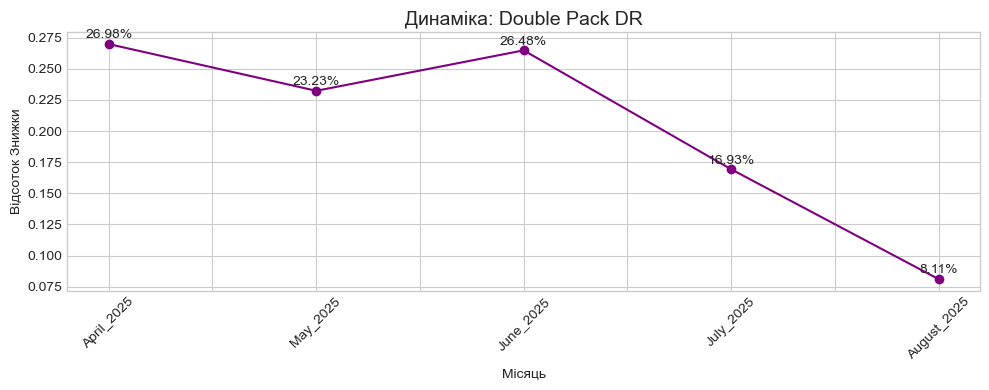

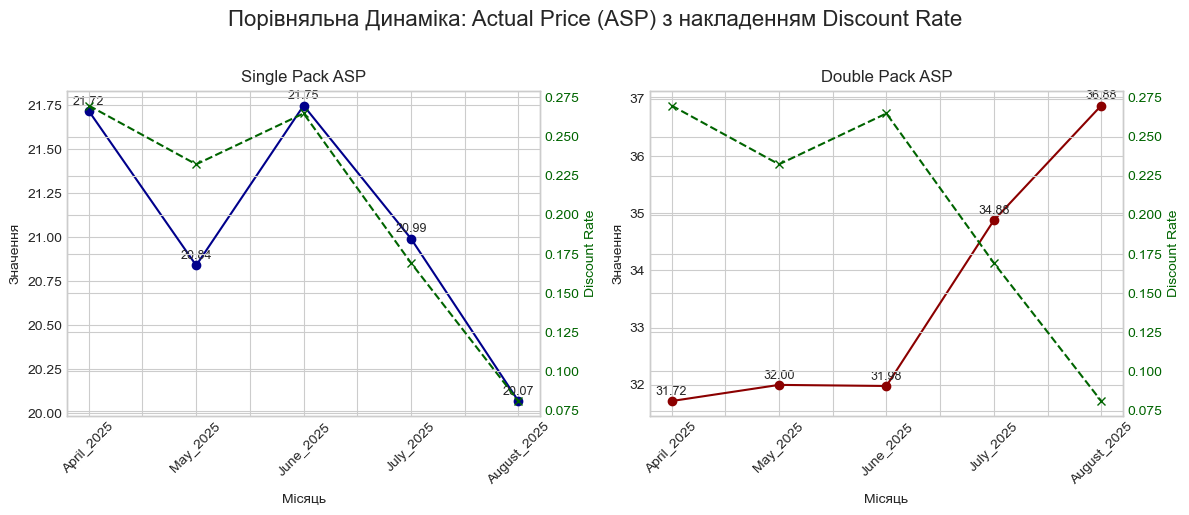

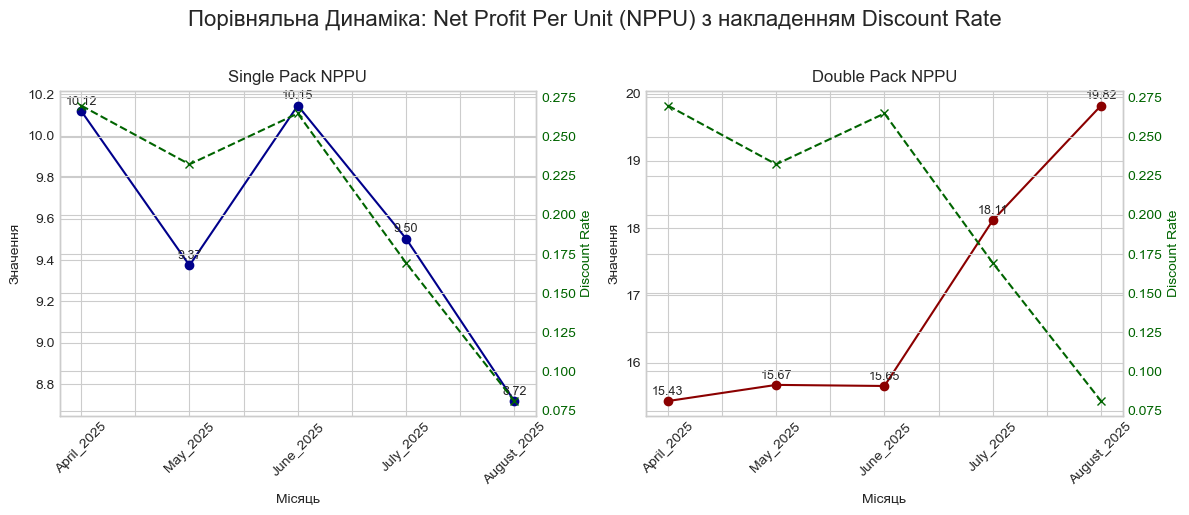


--- Аналіз стратегічних KPI завершено. ---


In [15]:
# Встановлення стилю для графіків
plt.style.use('seaborn-v0_8-whitegrid')

# Припускаємо, що функція create_sort_key та df_comparison_pivot визначені

# --- КРОК 3.1: Розрахунок та Аналіз Стратегічних KPI (ФІНАЛЬНИЙ КОД) ---

# 1. Підготовка робочого датасету: Трансформація MultiIndex
df_work = df_comparison_pivot.T.copy()
df_work.index.names = ['Month_Year', 'Pack_Type']
df_work = df_work.unstack(level='Pack_Type')

# Визначаємо скорочену технічну назву для Discount Rate
discount_key_short = 'Double Pack DR' 

# 2. Розрахунок ASP
for pack in ['Single Pack', 'Double Pack']:
    col_key = f'{pack} ASP'
    df_work[(col_key, '')] = df_work[('Ordered Product Sales', pack)] / df_work[('Units Ordered', pack)]

# 3. Розрахунок NPPU
for pack in ['Single Pack', 'Double Pack']:
    col_key = f'{pack} NPPU'
    df_work[(col_key, '')] = df_work[('Net Profit', pack)] / df_work[('Units Ordered', pack)]

# 4. Розрахунок Discount Rate (DR)
df_work[(discount_key_short, '')] = 1 - (
    df_work[('Double Pack ASP', '')] / (2 * df_work[('Single Pack ASP', '')])
)

# 5. Створення фінального стратегічного датасету
final_cols = [
    ('Single Pack ASP', ''),
    ('Double Pack ASP', ''),
    ('Single Pack NPPU', ''),
    ('Double Pack NPPU', ''),
    (discount_key_short, '') 
]

df_strategic_kpi = df_work[final_cols].copy()

# 6. Очищення та Спрощення MultiIndex колонок
df_strategic_kpi.columns = df_strategic_kpi.columns.get_level_values(0)
df_strategic_kpi.index.name = 'Month_Year'

# 7. Транспонування та Сортування
df_strategic_kpi_final = df_strategic_kpi.T
df_strategic_kpi_final.index.name = 'KPI'

sorted_months = sorted(df_strategic_kpi_final.columns, key=create_sort_key)
df_strategic_kpi_final = df_strategic_kpi_final[sorted_months]

# --- ВИВЕДЕННЯ ТАБЛИЦІ (ЗБЕРЕЖЕННЯ ЧИСЛОВОГО ТИПУ) ---
print(f"\n--- Звіт Single vs Double Pack (Крок 3.1: Стратегічні KPI) ---")
print("Таблиця помісячних стратегічних показників (Показники в рядках, Місяці в колонках):")

def format_strategic_kpi(df):
    """Стилізація для стратегічних KPI."""
    format_dict = {}
    for index_name in df.index:
        # ЗАЛИШАЄМО СТАНДАРТНЕ ФОРМАТУВАННЯ, яке має працювати
        if 'ASP' in index_name or 'NPPU' in index_name:
            format_dict[index_name] = '{:,.2f}' 
        elif 'DR' in index_name:
            format_dict[index_name] = '{:.2%}'

    # df_strategic_kpi_final ЗБЕРІГАЄ числовий тип даних
    styled_df = df.style.format(format_dict)
    
    # Виділення Discount Rate
    styled_df = styled_df.apply(lambda x: ['background-color: lightyellow' if x.name == discount_key_short else '' for i in x], axis=1)
    return styled_df

display(df_strategic_kpi_final.pipe(format_strategic_kpi))


# --- ВІЗУАЛІЗАЦІЯ (Фіналізована версія з накладенням DR) ---

print("\n--- Візуальний Аналіз Стратегічних KPI ---")

comparison_metrics = [
    'Single Pack ASP', 
    'Double Pack ASP',
    'Single Pack NPPU', 
    'Double Pack NPPU'
]

metric_pairs = [(comparison_metrics[i], comparison_metrics[i+1]) for i in range(0, len(comparison_metrics), 2)]
single_metric_plot = discount_key_short 
colors = ['darkblue', 'darkred']
discount_color = 'darkgreen' 
discount_data = df_strategic_kpi_final.loc[single_metric_plot]

# 1. Окремий графік Double Pack DR 
plt.figure(figsize=(10, 4)) 

ax_dr = discount_data.plot(marker='o', linestyle='-', color='purple')
plt.title(f'Динаміка: {single_metric_plot}', fontsize=14)
plt.xlabel('Місяць')
plt.ylabel('Відсоток Знижки')
plt.xticks(rotation=45)

y_min_dr, y_max_dr = ax_dr.get_ylim()
for x, y in enumerate(discount_data):
    ax_dr.text(x, y + (y_max_dr - y_min_dr) * 0.01, f'{y:.2%}', ha='center', va='bottom', fontsize=10)
    
plt.tight_layout()
plt.show()


# 2. Попарні графіки ASP та NPPU з накладеною лінією DR
for metric1, metric2 in metric_pairs:
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 
    
    if 'ASP' in metric1:
        suptitle = 'Порівняльна Динаміка: Actual Price (ASP) з накладенням Discount Rate'
    else:
        suptitle = 'Порівняльна Динаміка: Net Profit Per Unit (NPPU) з накладенням Discount Rate'
        
    fig.suptitle(suptitle, fontsize=16, y=1.02)
    
    data1 = df_strategic_kpi_final.loc[metric1]
    data2 = df_strategic_kpi_final.loc[metric2]
    
    # --- ГРАФІК 1: Single Pack (ASP або NPPU) ---
    data1.plot(ax=axes[0], marker='o', linestyle='-', color=colors[0], label=metric1)
    axes[0].set_title(metric1, fontsize=12) 
    axes[0].set_xlabel('Місяць')
    axes[0].set_ylabel('Значення')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Накладання Double Pack DR
    ax_dr1 = axes[0].twinx() 
    ax_dr1.plot(discount_data.index, discount_data.values, marker='x', linestyle='--', color=discount_color, label=single_metric_plot)
    ax_dr1.set_ylabel('Discount Rate', color=discount_color)
    ax_dr1.tick_params(axis='y', labelcolor=discount_color)
    
    # Додавання підписів
    y_min_ax1, y_max_ax1 = axes[0].get_ylim()
    for x, y in enumerate(data1):
        axes[0].text(x, y + (y_max_ax1 - y_min_ax1) * 0.01, f'{y:,.2f}', ha='center', va='bottom', fontsize=9)
    
    # --- ГРАФІК 2: Double Pack (ASP або NPPU) ---
    data2.plot(ax=axes[1], marker='o', linestyle='-', color=colors[1], label=metric2)
    axes[1].set_title(metric2, fontsize=12) 
    axes[1].set_xlabel('Місяць')
    axes[1].set_ylabel('Значення')
    axes[1].tick_params(axis='x', rotation=45)

    # Накладання Double Pack DR
    ax_dr2 = axes[1].twinx() 
    ax_dr2.plot(discount_data.index, discount_data.values, marker='x', linestyle='--', color=discount_color, label=single_metric_plot)
    ax_dr2.set_ylabel('Discount Rate', color=discount_color)
    ax_dr2.tick_params(axis='y', labelcolor=discount_color)

    # Додавання підписів
    y_min_ax2, y_max_ax2 = axes[1].get_ylim()
    for x, y in enumerate(data2):
        axes[1].text(x, y + (y_max_ax2 - y_min_ax2) * 0.01, f'{y:,.2f}', ha='center', va='bottom', fontsize=9)
        
    plt.tight_layout()
    plt.show()

print("\n--- Аналіз стратегічних KPI завершено. ---")

<h1 style="color: #0000FF;">📈КРОК 3.2: Аналіз відносних KPI з накладанням знижки Double Pack (DR)</h1>

Розрахунок додаткових **відносних показників**, які нормалізують продажі та прибутковість до обсягів трафіку (сесій). Порівняння цих відносних метрик із динамікою знижки Double Pack (DR) допоможе нам виявити історичні закономірності та визначити фактори, що найбільше впливають на рішення про купівлю.

| Технічна Назва (у коді) | Повне Значення та Опис | Формула |
| :--- | :--- | :--- |
| **Double Pack DR** | **Discount Rate**: Відсоток знижки Double Pack відносно двох Single Pack'ів (з Кроку 3.1). | $1 - (\frac{\text{Double Pack ASP}}{\text{2} \times \text{Single Pack ASP}})$ |
| **Single Pack Sessions** | Кількість унікальних сесій, що переглядали Single Pack. | Дані з Кроку 2.6 |
| **Double Pack Sessions** | Кількість унікальних сесій, що переглядали Double Pack. | Дані з Кроку 2.6 |
| **Single Pack CR** | **Conversion Rate Single Pack**: Конверсія Single Pack. | $\frac{\text{Units Ordered (SP)}}{\text{Sessions (SP)}}$ |
| **Double Pack CR** | **Conversion Rate Double Pack**: Конверсія Double Pack. | $\frac{\text{Units Ordered (DB)}}{\text{Sessions (DB)}}$ |
| **Double Pack CR (vs Single Sessions)** | **Конверсія Double Pack відносно трафіку Single Pack**.<br>Вимірює, скільки продажів DB генерується з основного трафіку SP. | $\frac{\text{Units Ordered (DB)}}{\text{Sessions (SP)}}$ |
| **Single Pack NPPS** | **Net Profit Per Single Session**: Чистий прибуток від SP на одну сесію SP. | $\frac{\text{Net Profit (SP)}}{\text{Sessions (SP)}}$ |
| **Double Pack NPPS** | **Net Profit Per Double Session**: Чистий прибуток від DB на одну сесію DB. | $\frac{\text{Net Profit (DB)}}{\text{Sessions (DB)}}$ |
| **Units Ordered Ratio (DB/S)** | **Співвідношення Обсягу Замовлень**: Частка DB у продажах відносно SP. | $\frac{\text{Units Ordered (DB)}}{\text{Units Ordered (SP)}}$ |
| **Net Profit Ratio (DB/S)** | **Співвідношення Чистого Прибутку**: Частка прибутку від DB відносно SP. | $\frac{\text{Net Profit (DB)}}{\text{Net Profit (SP)}}$ |

**Візуалізація:**
Графіки дозволяють візуально оцінити, як зміна **Discount Rate** корелює з найважливішими показниками — трафіком, конверсією та відносною прибутковістю. Це є основою для подальшого регресійного аналізу.


--- Звіт Single vs Double Pack (Крок 3.2: Аналіз Відносних KPI) ---
Таблиця помісячних відносних показників (Показники в рядках, Місяці в колонках):


Month_Year,April_2025,May_2025,June_2025,July_2025,August_2025
KPI,,,,,
Double Pack DR,0.269833,0.232307,0.264802,0.169311,0.081084
Single Pack Sessions,11845.000000,14038.000000,9473.000000,16315.000000,20046.000000
Double Pack Sessions,1255.000000,1580.000000,1109.000000,1716.000000,1880.000000
Single Pack CR,0.374082,0.375908,0.405257,0.361017,0.364462
Double Pack CR,0.454183,0.477215,0.595131,0.513403,0.452660
Double Pack CR (vs Single Sessions),0.048122,0.053711,0.069672,0.053999,0.042452
Single Pack NPPS,3.785724,3.523854,4.111799,3.430895,3.177768
Double Pack NPPS,7.007060,7.477101,9.314968,9.300117,8.972489
Units Ordered Ratio (DB/S),0.128639,0.142884,0.171920,0.149576,0.116480



--- Візуальний Аналіз Відносних KPI та Знижки (DR) ---


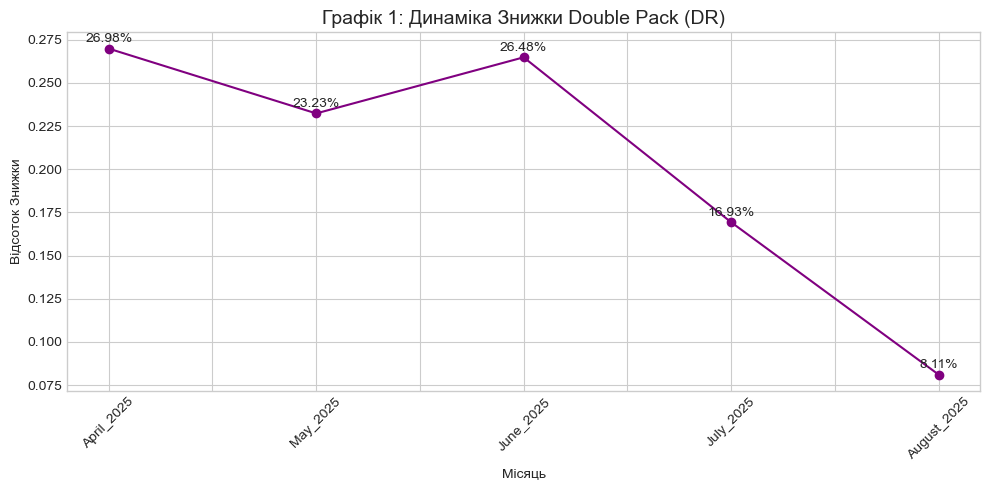

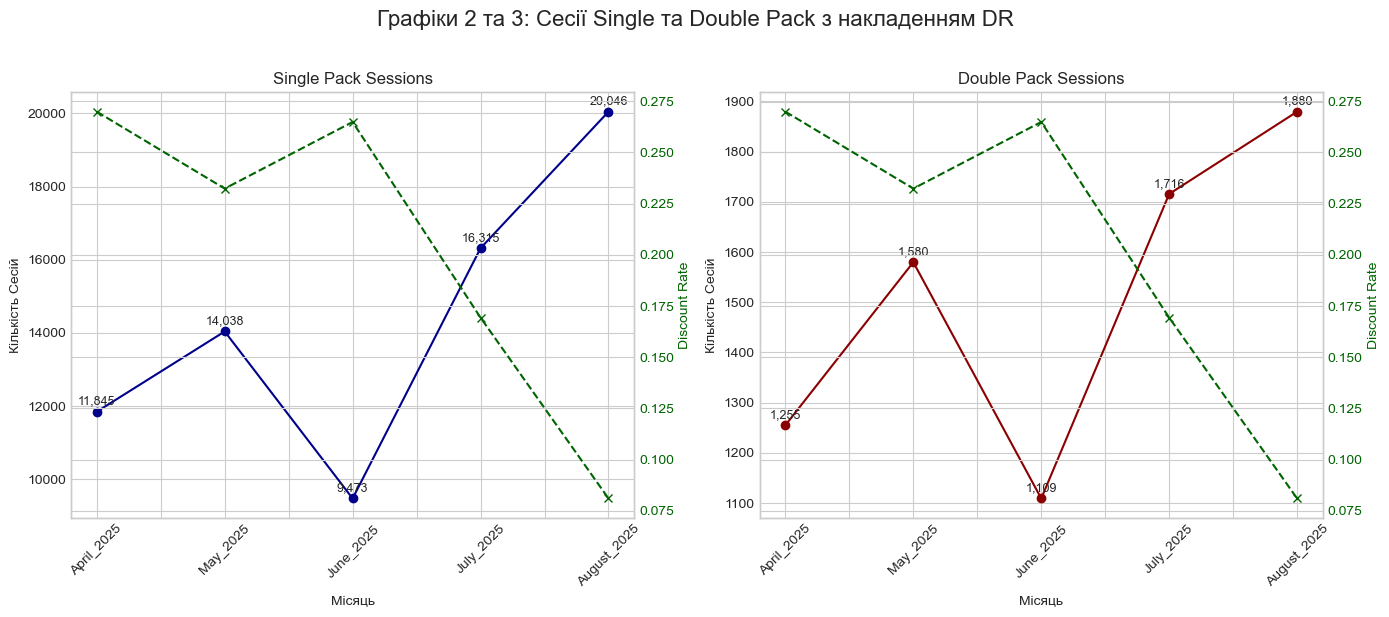

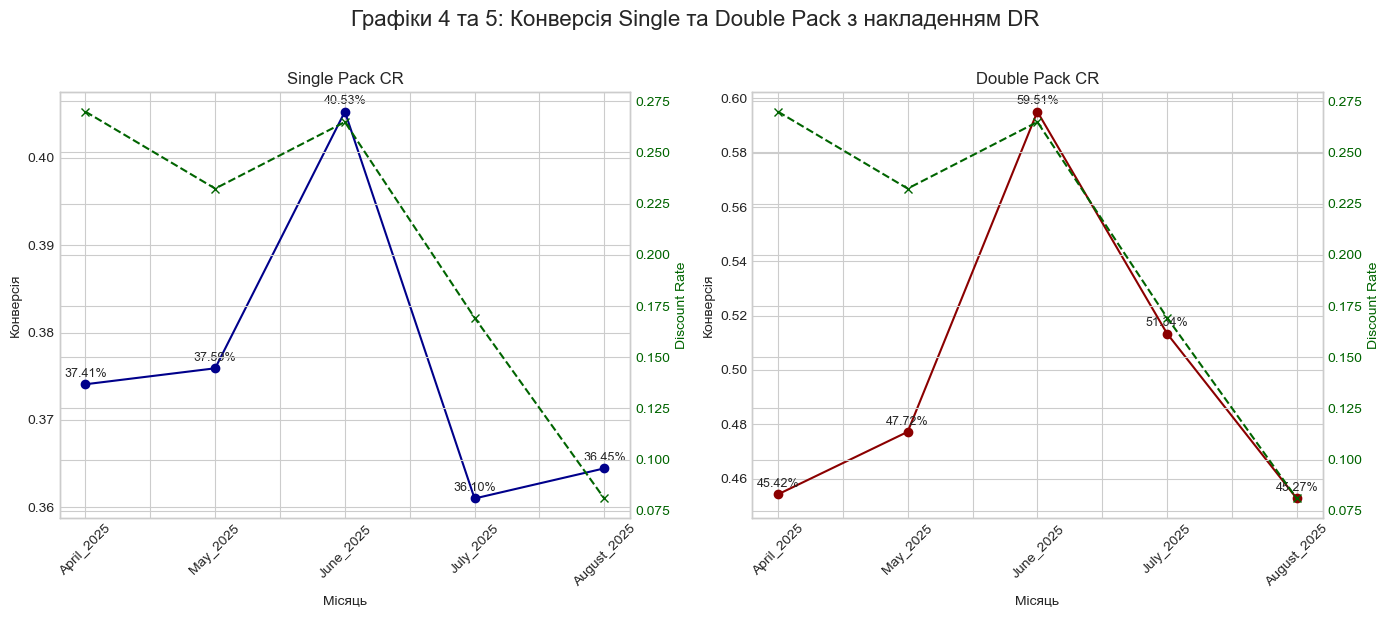

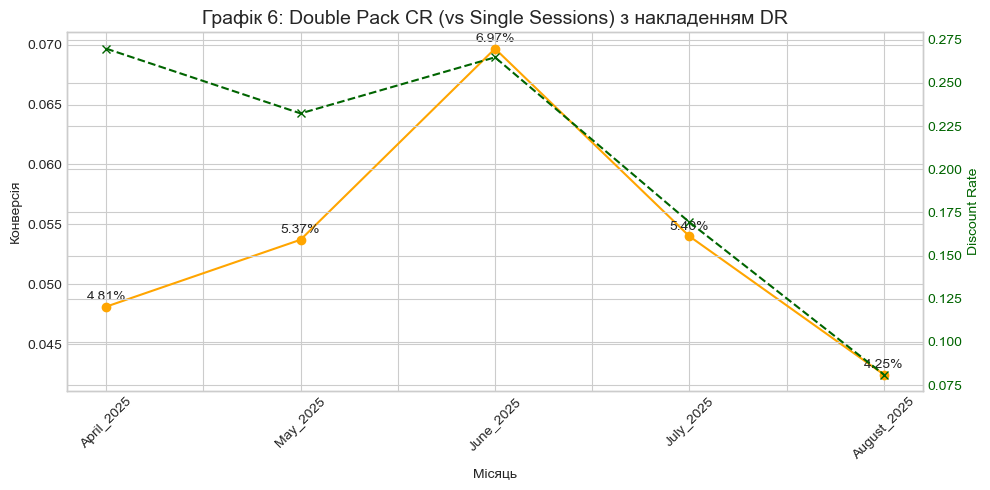

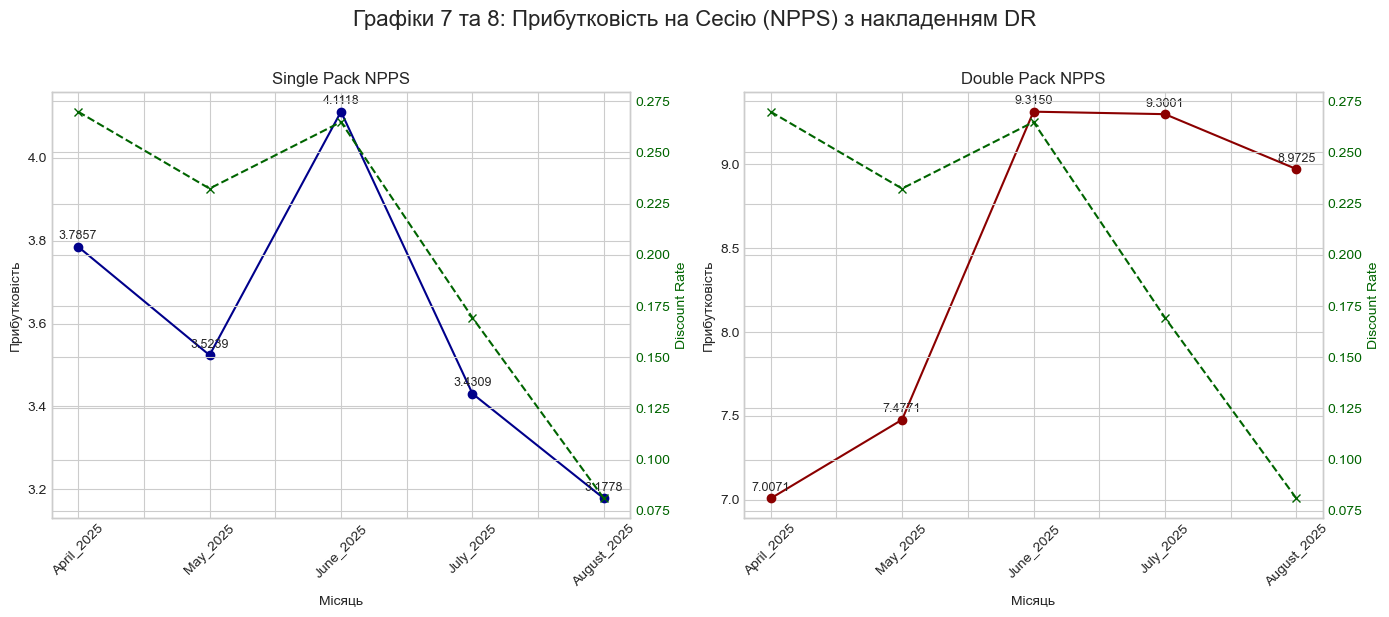

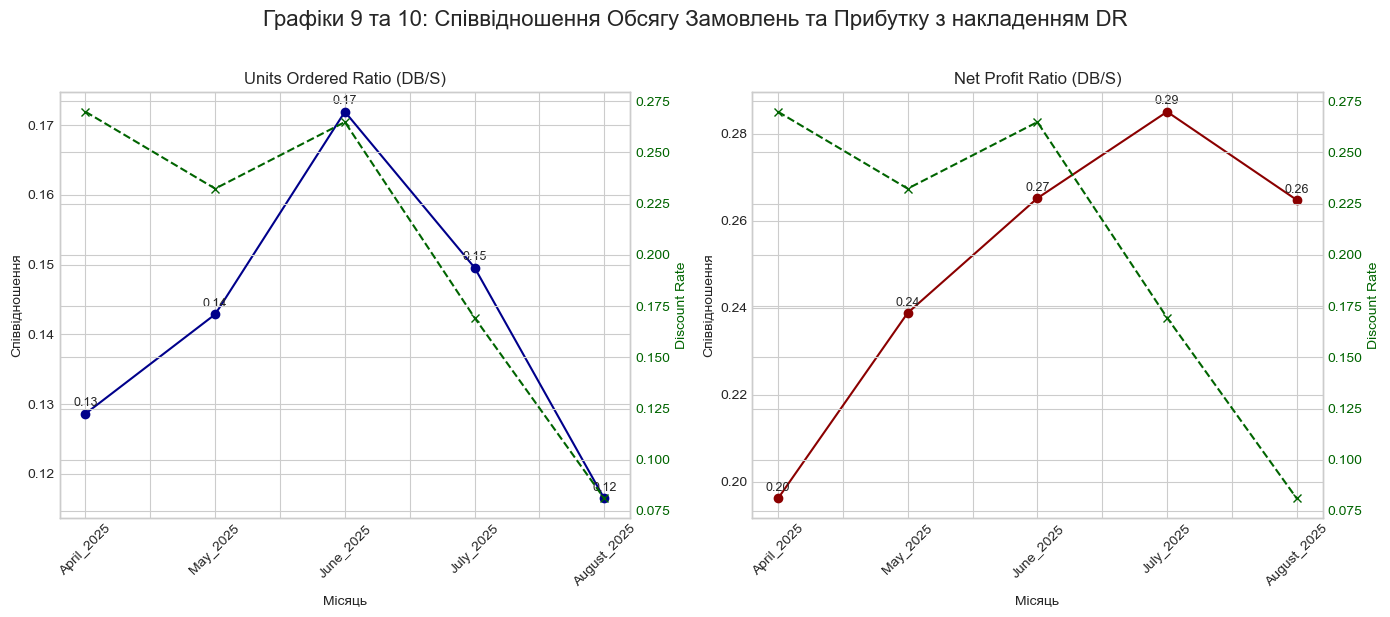


--- Розрахунок та візуалізація відносних KPI завершено. ---


In [16]:
# Припускаємо, що df_comparison_pivot (Крок 2.6) та df_strategic_kpi_final (Крок 3.1)
# та create_sort_key визначені.

# 1. Підготовка даних
# Використовуємо df_strategic_kpi_final (числовий DF з DR)
# та df_comparison_pivot (числовий DF з основними показниками)

df_kpi_base = df_strategic_kpi_final.T.copy()
df_kpi_base.index.name = 'Month_Year'

# Транспонуємо df_comparison_pivot та розгортаємо, щоб легко дістати дані
df_comp_unstack = df_comparison_pivot.T.unstack(level='Pack_Type')


# --- СЕКЦІЯ 1: Розрахунок KPI ---

# 1.1 Сесії та Співвідношення Сесій
sessions_single = df_comp_unstack[('Sessions', 'Single Pack')]
sessions_double = df_comp_unstack[('Sessions', 'Double Pack')]

df_kpi_base['Double Pack Sessions Ratio'] = sessions_double / sessions_single


# 1.2 Конверсія
units_single = df_comp_unstack[('Units Ordered', 'Single Pack')]
units_double = df_comp_unstack[('Units Ordered', 'Double Pack')]

# Перший показник конверсії
df_kpi_base['Single Pack CR'] = units_single / sessions_single
# Другий показник конверсії
df_kpi_base['Double Pack CR'] = units_double / sessions_double
# Третій показник конверсії
df_kpi_base['Double Pack CR (vs Single Sessions)'] = units_double / sessions_single


# 1.3 Прибутковість на Сесію
net_profit_single = df_comp_unstack[('Net Profit', 'Single Pack')]
net_profit_double = df_comp_unstack[('Net Profit', 'Double Pack')]

# Перший показник прибутковості на сесію
df_kpi_base['Single Pack NPPS'] = net_profit_single / sessions_single
# Другий показник прибутковості на сесію
df_kpi_base['Double Pack NPPS'] = net_profit_double / sessions_double


# 1.4 Співвідношення Обсягу та Прибутку
# Показник відношення кількості замовлень
df_kpi_base['Units Ordered Ratio (DB/S)'] = units_double / units_single
# Показник відношення нет профіту
df_kpi_base['Net Profit Ratio (DB/S)'] = net_profit_double / net_profit_single


# --- СЕКЦІЯ 2: Формування Фінальної Таблиці ---

# 2.1 Створення нового датафрейму для виведення
df_kpi_display = pd.DataFrame({
    # 1. Показник знижки
    'Double Pack DR': df_kpi_base['Double Pack DR'],
    # 2. Сесії на сінглпак
    'Single Pack Sessions': sessions_single,
    # 3. Сесії на даблпак
    'Double Pack Sessions': sessions_double,
    # 4. Перший показник конверсії
    'Single Pack CR': df_kpi_base['Single Pack CR'],
    # 5. Другий показник конверсії
    'Double Pack CR': df_kpi_base['Double Pack CR'],
    # 6. Третій показник конверсії
    'Double Pack CR (vs Single Sessions)': df_kpi_base['Double Pack CR (vs Single Sessions)'],
    # 7. Перший показник прибутковості на сесію
    'Single Pack NPPS': df_kpi_base['Single Pack NPPS'],
    # 8. Другий показник прибутковості на сесію
    'Double Pack NPPS': df_kpi_base['Double Pack NPPS'],
    # 9. Показник відношення кількості замовлень
    'Units Ordered Ratio (DB/S)': df_kpi_base['Units Ordered Ratio (DB/S)'],
    # 10. Показник відношення нет профіту
    'Net Profit Ratio (DB/S)': df_kpi_base['Net Profit Ratio (DB/S)'],
})

# 2.2 Транспонування та Сортування
df_kpi_final_3_2 = df_kpi_display.T
df_kpi_final_3_2 = df_kpi_final_3_2[sorted_months]
df_kpi_final_3_2.index.name = 'KPI'


# 2.3 Функція для стилізації таблиці (збереження числових типів)
def format_kpi_3_2(df):
    format_dict = {}
    for index_name in df.index:
        if 'Sessions' in index_name:
            # Сесії - цілі числа
            format_dict[index_name] = '{:,.0f}' 
        elif 'CR' in index_name or 'Ratio' in index_name:
            # Конверсія та співвідношення - 2 знаки після коми
            format_dict[index_name] = '{:.2%}' if 'CR' in index_name else '{:,.2f}'
        elif 'NPPS' in index_name:
            # Прибуток на сесію - 4 знаки (мала величина)
            format_dict[index_name] = '{:,.4f}'
        elif 'DR' in index_name:
            # Discount Rate - 2 знаки відсотка
            format_dict[index_name] = '{:.2%}' 

    # ЗАСТОСУВАННЯ СТИЛЮ. Тип даних не змінюється!
    styled_df = df.style.format(format_dict)
    
    # Виділення DR
    styled_df = styled_df.apply(lambda x: ['background-color: lightyellow' if x.name == 'Double Pack DR' else '' for i in x], axis=1)
    return styled_df

print(f"\n--- Звіт Single vs Double Pack (Крок 3.2: Аналіз Відносних KPI) ---")
print("Таблиця помісячних відносних показників (Показники в рядках, Місяці в колонках):")
display(df_kpi_final_3_2.pipe(format_kpi_3_2))


# --- СЕКЦІЯ 3: Візуалізація ---

print("\n--- Візуальний Аналіз Відносних KPI та Знижки (DR) ---")

# DR data - використовуємо DR з df_kpi_base (числовий)
dr_data = df_kpi_base['Double Pack DR']
dr_color = 'darkgreen' 


# 3.1 Перший графік: Double Pack DR (окремо)
plt.figure(figsize=(10, 5))
ax1 = dr_data.plot(marker='o', linestyle='-', color='purple')
plt.title('Графік 1: Динаміка Знижки Double Pack (DR)', fontsize=14)
plt.xlabel('Місяць')
plt.ylabel('Відсоток Знижки')
plt.xticks(rotation=45)

# Додавання підписів
y_min_ax1, y_max_ax1 = ax1.get_ylim()
for x, y in enumerate(dr_data):
    ax1.text(x, y + (y_max_ax1 - y_min_ax1) * 0.01, f'{y:.2%}', ha='center', va='bottom', fontsize=10)
    
plt.tight_layout()
plt.show()


# 3.2 Другий та третій графіки: Сесії + DR
sessions_metrics = ['Single Pack Sessions', 'Double Pack Sessions']
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
fig.suptitle('Графіки 2 та 3: Сесії Single та Double Pack з накладенням DR', fontsize=16, y=1.02)

for i, metric in enumerate(sessions_metrics):
    data = df_kpi_final_3_2.loc[metric]
    
    ax = axes[i]
    data.plot(ax=ax, marker='o', linestyle='-', color=['darkblue', 'darkred'][i], label=metric)
    ax.set_title(metric, fontsize=12) 
    ax.set_xlabel('Місяць')
    ax.set_ylabel('Кількість Сесій')
    ax.tick_params(axis='x', rotation=45)
    
    # Накладання DR
    ax_dr = ax.twinx() 
    ax_dr.plot(dr_data.index, dr_data.values, marker='x', linestyle='--', color=dr_color, label='Double Pack DR')
    ax_dr.set_ylabel('Discount Rate', color=dr_color)
    ax_dr.tick_params(axis='y', labelcolor=dr_color)
    
    # Підписи для Сесій
    y_min, y_max = ax.get_ylim()
    for x_idx, y_val in enumerate(data):
        ax.text(x_idx, y_val + (y_max - y_min) * 0.01, f'{y_val:,.0f}', ha='center', va='bottom', fontsize=9)
        
plt.tight_layout()
plt.show()


# 3.3 Четвертий та п'ятий графіки: Конверсія CR + DR
cr_metrics = ['Single Pack CR', 'Double Pack CR']
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
fig.suptitle('Графіки 4 та 5: Конверсія Single та Double Pack з накладенням DR', fontsize=16, y=1.02)

for i, metric in enumerate(cr_metrics):
    data = df_kpi_final_3_2.loc[metric]
    
    ax = axes[i]
    data.plot(ax=ax, marker='o', linestyle='-', color=['darkblue', 'darkred'][i], label=metric)
    ax.set_title(metric, fontsize=12) 
    ax.set_xlabel('Місяць')
    ax.set_ylabel('Конверсія')
    ax.tick_params(axis='x', rotation=45)
    
    # Накладання DR
    ax_dr = ax.twinx() 
    ax_dr.plot(dr_data.index, dr_data.values, marker='x', linestyle='--', color=dr_color, label='Double Pack DR')
    ax_dr.set_ylabel('Discount Rate', color=dr_color)
    ax_dr.tick_params(axis='y', labelcolor=dr_color)
    
    # Підписи для CR
    y_min, y_max = ax.get_ylim()
    for x_idx, y_val in enumerate(data):
        ax.text(x_idx, y_val + (y_max - y_min) * 0.01, f'{y_val:.2%}', ha='center', va='bottom', fontsize=9)
        
plt.tight_layout()
plt.show()


# 3.4 Шостий графік: Конверсія Double Pack (vs Single Sessions) + DR (окремо)
plt.figure(figsize=(10, 5)) 
metric = 'Double Pack CR (vs Single Sessions)'
data = df_kpi_final_3_2.loc[metric]

ax = data.plot(marker='o', linestyle='-', color='orange')
plt.title(f'Графік 6: {metric} з накладенням DR', fontsize=14)
plt.xlabel('Місяць')
plt.ylabel('Конверсія')
plt.xticks(rotation=45)

# Накладання DR
ax_dr = ax.twinx() 
ax_dr.plot(dr_data.index, dr_data.values, marker='x', linestyle='--', color=dr_color, label='Double Pack DR')
ax_dr.set_ylabel('Discount Rate', color=dr_color)
ax_dr.tick_params(axis='y', labelcolor=dr_color)

# Підписи
y_min, y_max = ax.get_ylim()
for x_idx, y_val in enumerate(data):
    ax.text(x_idx, y_val + (y_max - y_min) * 0.01, f'{y_val:.2%}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


# 3.5 Сьомий та восьмий графіки: Прибутковість на Сесію (NPPS) + DR
npps_metrics = ['Single Pack NPPS', 'Double Pack NPPS']
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
fig.suptitle('Графіки 7 та 8: Прибутковість на Сесію (NPPS) з накладенням DR', fontsize=16, y=1.02)

for i, metric in enumerate(npps_metrics):
    data = df_kpi_final_3_2.loc[metric]
    
    ax = axes[i]
    data.plot(ax=ax, marker='o', linestyle='-', color=['darkblue', 'darkred'][i], label=metric)
    ax.set_title(metric, fontsize=12) 
    ax.set_xlabel('Місяць')
    ax.set_ylabel('Прибутковість')
    ax.tick_params(axis='x', rotation=45)
    
    # Накладання DR
    ax_dr = ax.twinx() 
    ax_dr.plot(dr_data.index, dr_data.values, marker='x', linestyle='--', color=dr_color, label='Double Pack DR')
    ax_dr.set_ylabel('Discount Rate', color=dr_color)
    ax_dr.tick_params(axis='y', labelcolor=dr_color)
    
    # Підписи
    y_min, y_max = ax.get_ylim()
    for x_idx, y_val in enumerate(data):
        ax.text(x_idx, y_val + (y_max - y_min) * 0.01, f'{y_val:,.4f}', ha='center', va='bottom', fontsize=9)
        
plt.tight_layout()
plt.show()


# 3.6 Девятий та десятий графіки: Співвідношення (Ratio) + DR
ratio_metrics = ['Units Ordered Ratio (DB/S)', 'Net Profit Ratio (DB/S)']
fig, axes = plt.subplots(1, 2, figsize=(14, 6)) 
fig.suptitle('Графіки 9 та 10: Співвідношення Обсягу Замовлень та Прибутку з накладенням DR', fontsize=16, y=1.02)

for i, metric in enumerate(ratio_metrics):
    data = df_kpi_final_3_2.loc[metric]
    
    ax = axes[i]
    data.plot(ax=ax, marker='o', linestyle='-', color=['darkblue', 'darkred'][i], label=metric)
    ax.set_title(metric, fontsize=12) 
    ax.set_xlabel('Місяць')
    ax.set_ylabel('Співвідношення')
    ax.tick_params(axis='x', rotation=45)
    
    # Накладання DR
    ax_dr = ax.twinx() 
    ax_dr.plot(dr_data.index, dr_data.values, marker='x', linestyle='--', color=dr_color, label='Double Pack DR')
    ax_dr.set_ylabel('Discount Rate', color=dr_color)
    ax_dr.tick_params(axis='y', labelcolor=dr_color)
    
    # Підписи
    y_min, y_max = ax.get_ylim()
    for x_idx, y_val in enumerate(data):
        ax.text(x_idx, y_val + (y_max - y_min) * 0.01, f'{y_val:,.2f}', ha='center', va='bottom', fontsize=9)
        
plt.tight_layout()
plt.show()


print("\n--- Розрахунок та візуалізація відносних KPI завершено. ---")

<h1 style="color: #0000FF;">КРОК 3.3: Розрахунок та аналіз конверсійних метрик</h1>

Цей крок має вирішальне значення для розуміння **взаємодії** між $\text{Single Pack}$ (основним продуктом) та $\text{Double Pack}$ (крос-сейл продуктом). Ми розрахуємо ключові конверсійні показники та візуалізуємо їхній зв'язок зі **Знижкою на Double Pack (DP DR)**.

## 🛠️ Розрахункові Показники та Формули

| Назва Показника | Абревіатура | Опис | Формула |
| :--- | :--- | :--- | :--- |
| **Sessions Single Pack** | $\text{SP\_Sessions}$ | Загальна кількість відвідувань сторінки $\text{Single Pack}$ на місяць. | $\text{Sessions}_{\text{SP}}$ |
| **Sessions Double Pack** | $\text{DP\_Sessions}$ | Загальна кількість відвідувань сторінки $\text{Double Pack}$ на місяць. | $\text{Sessions}_{\text{DP}}$ |
| **Traffic Attraction Rate** | $\text{TAR}$ | Коефіцієнт залучення трафіку. Показує, яка частка відвідувачів, що прийшли на $\text{SP}$, **в принципі зацікавилась** $\text{DP}$. | $\frac{\text{Sessions}_{\text{DP}}}{\text{Sessions}_{\text{SP}}}$ |
| **SP Conversion Rate** | $\text{SP\_CR}$ | Конверсія продажів $\text{Single Pack}$. Скільки відвідувачів сторінки $\text{SP}$ здійснили покупку $\text{SP}$. | $\frac{\text{Units Ordered}_{\text{SP}}}{\text{Sessions}_{\text{SP}}}$ |
| **DP Conversion Rate** | $\text{DP\_CR}$ | Конверсія продажів $\text{Double Pack}$. Скільки відвідувачів сторінки $\text{DP}$ здійснили покупку $\text{DP}$. | $\frac{\text{Units Ordered}_{\text{DP}}}{\text{Sessions}_{\text{DP}}}$ |
| **Cross-Sale Conversion** | $\text{CSC}$ | Крос-продажна конверсія. Показує, яка частка основного трафіку $\text{SP}$ була **конвертована безпосередньо** у продаж $\text{DP}$. | $\frac{\text{Units Ordered}_{\text{DP}}}{\text{Sessions}_{\text{SP}}}$ |
| **Double Pack Discount Rate**| $\text{DP\_DR}$ | Відсоток наданої знижки на $\text{Double Pack}$ за місяць. | $\text{Discount Rate}_{\text{DP}}$ |


--- Звіт Крок 3.3: Аналіз Конверсійних Метрик та Знижки (Double Pack) ---


### 📋 Таблиця Конверсійних Метрик

Month_Year,April_2025,May_2025,June_2025,July_2025,August_2025
SP_Sessions,11845,14038,9473,16315,20046
DP_Sessions,1255,1580,1109,1716,1880
TAR (DP Sessions / SP Sessions),0.1060,0.1126,0.1171,0.1052,0.0938
SP_CR (SP Units / SP Sessions),0.3741,0.3759,0.4053,0.3610,0.3645
DP_CR (DP Units / DP Sessions),0.4542,0.4772,0.5951,0.5134,0.4527
CSC (DP Units / SP Sessions),0.0481,0.0537,0.0697,0.0540,0.0425
DP_DR,0.2698,0.2323,0.2648,0.1693,0.0811



--- 4. Фінальна Візуалізація: Всі 6 графіків окремо (Зменшений розмір) ---


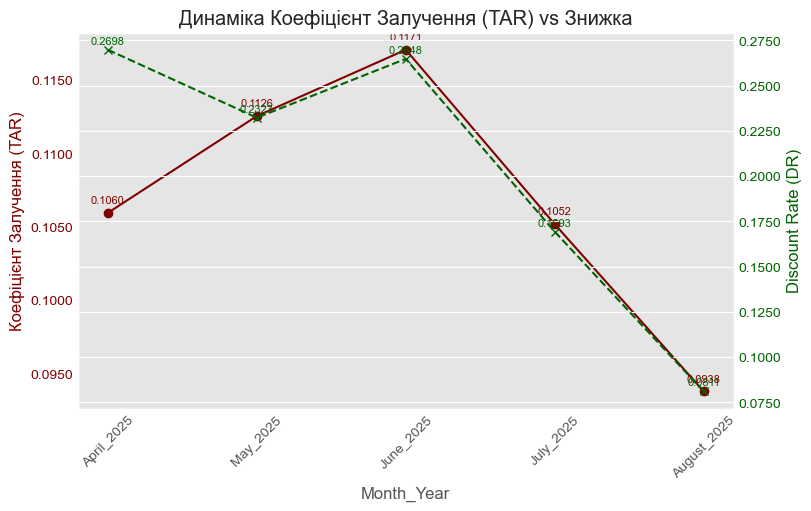

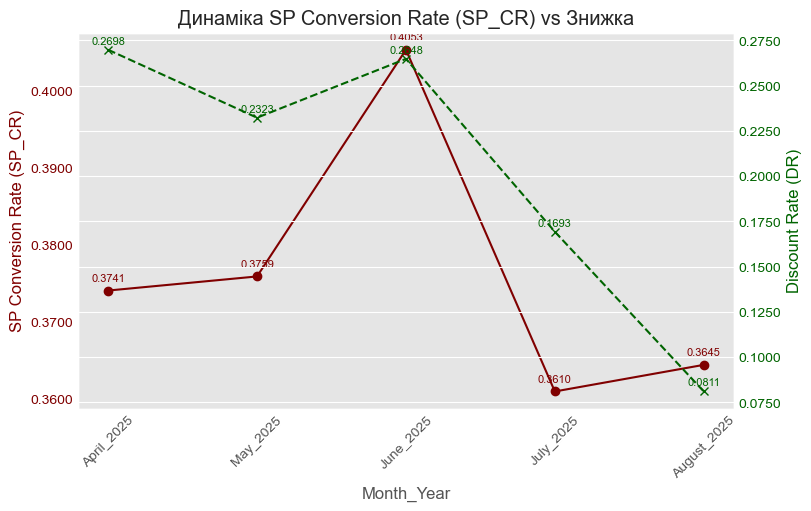

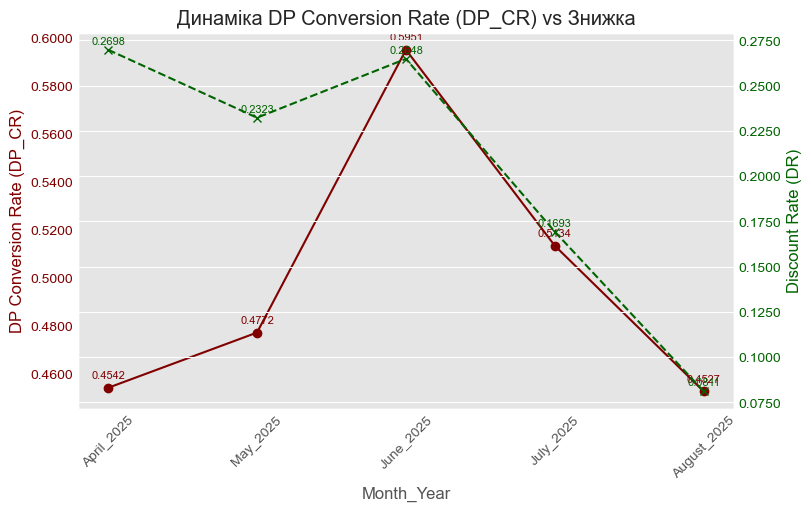

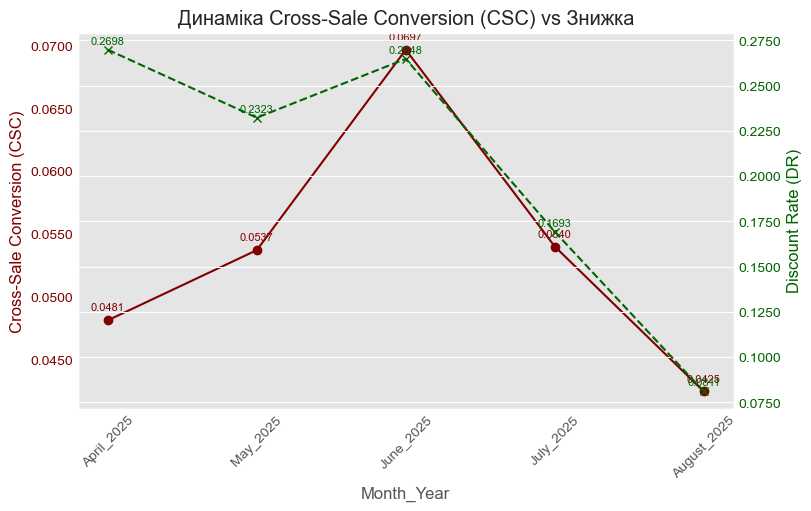

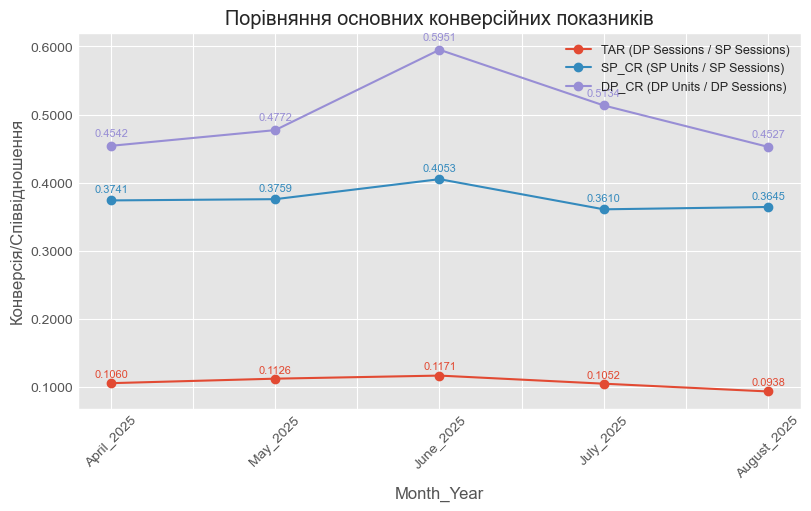

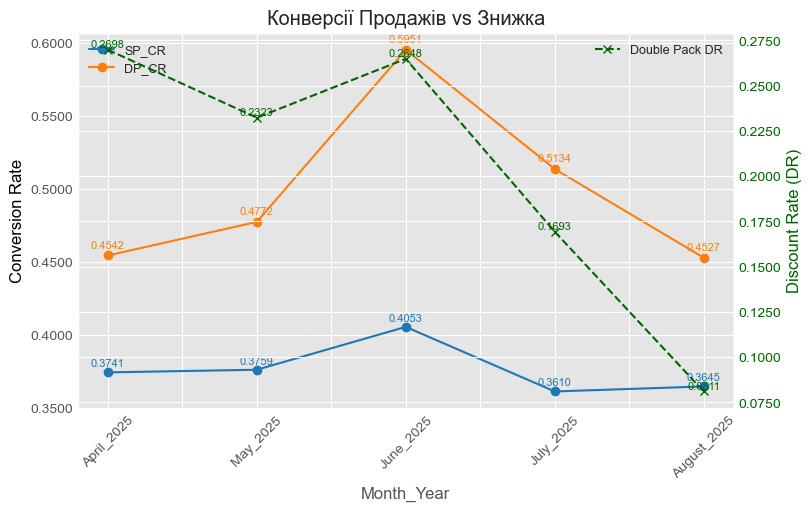

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Припускаємо, що df_comparison_pivot та df_strategic_kpi_final визначені

# --- 1. ПІДГОТОВКА ДАНИХ ---

# 1.1. Витягуємо необхідні серії з df_comparison_pivot (Мультиіндекс)
sp_sessions = df_comparison_pivot.loc['Sessions', (slice(None), 'Single Pack')]
dp_sessions = df_comparison_pivot.loc['Sessions', (slice(None), 'Double Pack')]
sp_units = df_comparison_pivot.loc['Units Ordered', (slice(None), 'Single Pack')]
dp_units = df_comparison_pivot.loc['Units Ordered', (slice(None), 'Double Pack')]

# 1.2. Вирівнювання індексів (Month_Year) та створення DataFrame
if sp_sessions.index.nlevels > 1:
    sp_sessions.index = sp_sessions.index.get_level_values('Month_Year')
    dp_sessions.index = dp_sessions.index.get_level_values('Month_Year')
    sp_units.index = sp_units.index.get_level_values('Month_Year')
    dp_units.index = dp_units.index.get_level_values('Month_Year')

df_model_analysis = pd.DataFrame({
    'SP_Sessions': sp_sessions,
    'DP_Sessions': dp_sessions,
    'SP_Units': sp_units,
    'DP_Units': dp_units
}).T.sort_index(axis=1).T

# 1.3. Додавання Discount Rate (DP_DR) з df_strategic_kpi_final
dp_dr_series = df_strategic_kpi_final.loc['Double Pack DR', :].copy()
dp_dr_series.name = 'DP_DR'

df_model_analysis = df_model_analysis.merge(dp_dr_series.to_frame(), 
                                            left_index=True, 
                                            right_index=True, 
                                            how='inner')
df_model_analysis = df_model_analysis.reset_index().rename(columns={'index': 'Month_Year'})

# --- ВИПРАВЛЕННЯ СОРТУВАННЯ ---
# Визначаємо правильний хронологічний порядок місяців (виходячи з вашої вибірки 5 місяців)
# Це критично, щоб уникнути алфавітного сортування
all_months = df_model_analysis['Month_Year'].unique()
# Припускаємо, що місяці мають формат "Month_YYYY" і охоплюють травень 2025 - вересень 2025
# Якщо порядок вхідних даних "April_2025, May_2025, June_2025, July_2025, August_2025", то використовуємо його:
month_order = ['April_2025', 'May_2025', 'June_2025', 'July_2025', 'August_2025']
month_order = [m for m in month_order if m in all_months] # Фільтруємо наявні місяці

df_model_analysis['Month_Year'] = pd.Categorical(df_model_analysis['Month_Year'], 
                                                 categories=month_order, 
                                                 ordered=True)
df_model_analysis = df_model_analysis.sort_values(by='Month_Year').reset_index(drop=True)
# --- КІНЕЦЬ ВИПРАВЛЕННЯ СОРТУВАННЯ ---


# --- 2. РОЗРАХУНОК КОНВЕРСІЙНИХ ПОКАЗНИКІВ (БЕЗ ЗМІН) ---

df_model_analysis['TAR (DP Sessions / SP Sessions)'] = df_model_analysis['DP_Sessions'] / df_model_analysis['SP_Sessions']
df_model_analysis['SP_CR (SP Units / SP Sessions)'] = df_model_analysis['SP_Units'] / df_model_analysis['SP_Sessions']
df_model_analysis['DP_CR (DP Units / DP Sessions)'] = df_model_analysis['DP_Units'] / df_model_analysis['DP_Sessions'].replace(0, np.nan)
df_model_analysis['CSC (DP Units / SP Sessions)'] = df_model_analysis['DP_Units'] / df_model_analysis['SP_Sessions']


# --- 3. ФОРМУВАННЯ ТАБЛИЦІ ВИВОДУ (БЕЗ ЗМІН) ---

df_output = df_model_analysis.set_index('Month_Year')

final_cols_order = [
    'SP_Sessions',
    'DP_Sessions',
    'TAR (DP Sessions / SP Sessions)',
    'SP_CR (SP Units / SP Sessions)',
    'DP_CR (DP Units / DP Sessions)',
    'CSC (DP Units / SP Sessions)',
    'DP_DR'
]

df_output = df_output[final_cols_order].T


def style_conversion_table(df):
    df_styled = df.copy()
    
    conversion_rows = [
        'TAR (DP Sessions / SP Sessions)',
        'SP_CR (SP Units / SP Sessions)',
        'DP_CR (DP Units / DP Sessions)',
        'CSC (DP Units / SP Sessions)',
        'DP_DR'
    ]
    
    style_obj = df_styled.style.format({
        col: '{:.0f}'.format
        for col in df_styled.columns
    }, subset=pd.IndexSlice[['SP_Sessions', 'DP_Sessions'], :])
    
    style_obj = style_obj.format({
        col: '{:.4f}'.format
        for col in df_styled.columns
    }, subset=pd.IndexSlice[conversion_rows, :])
    
    return style_obj

print("\n--- Звіт Крок 3.3: Аналіз Конверсійних Метрик та Знижки (Double Pack) ---")

# Вивід таблиці в окрему область для копіювання (відповідно до вашого запиту)
display(Markdown('### 📋 Таблиця Конверсійних Метрик'))
display(style_conversion_table(df_output))


# --- 4. Фінальна Візуалізація: Всі 6 графіків окремо (Зменшений розмір) ---

print("\n--- 4. Фінальна Візуалізація: Всі 6 графіків окремо (Зменшений розмір) ---")

plt.style.use('ggplot')

conversion_metrics = [
    ('TAR (DP Sessions / SP Sessions)', 'Коефіцієнт Залучення (TAR)'),
    ('SP_CR (SP Units / SP Sessions)', 'SP Conversion Rate (SP_CR)'),
    ('DP_CR (DP Units / DP Sessions)', 'DP Conversion Rate (DP_CR)'),
    ('CSC (DP Units / SP Sessions)', 'Cross-Sale Conversion (CSC)')
]

# 4.1. Виведення 4 індивідуальних графіків Конверсія vs DR
for metric_col, title in conversion_metrics:
    
    # ЗМЕНШЕННЯ РОЗМІРУ: figsize=(8, 5)
    fig, ax1 = plt.subplots(figsize=(8, 5), constrained_layout=True)  
    ax2 = ax1.twinx()  

    # Графік Конверсії
    ax1.plot(df_model_analysis['Month_Year'], df_model_analysis[metric_col], color='maroon', marker='o', label=title)
    ax1.set_ylabel(title, color='maroon')
    ax1.tick_params(axis='y', labelcolor='maroon')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(False)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.4f}'.format(y)))
    ax1.set_xlabel('Month_Year')

    # Додавання підписів до точок конверсії (ax1)
    y_min_ax1, y_max_ax1 = ax1.get_ylim()
    y_range_ax1 = y_max_ax1 - y_min_ax1
    if y_range_ax1 > 0:
        for x_idx, y_val in enumerate(df_model_analysis[metric_col]):
            if not pd.isna(y_val):
                 ax1.text(x_idx, y_val + y_range_ax1 * 0.02, f'{y_val:.4f}', ha='center', va='bottom', fontsize=8, color='maroon') 


    # Графік Discount Rate
    ax2.plot(df_model_analysis['Month_Year'], df_model_analysis['DP_DR'], color='darkgreen', linestyle='--', marker='x', label='Double Pack DR')
    ax2.set_ylabel('Discount Rate (DR)', color='darkgreen')
    ax2.tick_params(axis='y', labelcolor='darkgreen')
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.4f}'.format(y)))

    # Додавання підписів до точок знижки (ax2)
    y_min_ax2, y_max_ax2 = ax2.get_ylim()
    y_range_ax2 = y_max_ax2 - y_min_ax2
    if y_range_ax2 > 0:
        for x_idx, y_val in enumerate(df_model_analysis['DP_DR']):
            if not pd.isna(y_val):
                 ax2.text(x_idx, y_val + y_range_ax2 * 0.01, f'{y_val:.4f}', ha='center', va='bottom', fontsize=8, color='darkgreen') 


    ax1.set_title(f'Динаміка {title} vs Знижка')
    plt.show()

# 4.2. Графік 5: Три конверсії разом
metrics_g1 = ['TAR (DP Sessions / SP Sessions)', 'SP_CR (SP Units / SP Sessions)', 'DP_CR (DP Units / DP Sessions)']

# ЗМЕНШЕННЯ РОЗМІРУ: figsize=(8, 5)
fig, ax_g1 = plt.subplots(figsize=(8, 5), constrained_layout=True)

df_model_analysis.plot(
    x='Month_Year', 
    y=metrics_g1, 
    ax=ax_g1,
    kind='line',
    marker='o'
)
ax_g1.set_title('Порівняння основних конверсійних показників')
ax_g1.set_ylabel('Конверсія/Співвідношення')
ax_g1.tick_params(axis='x', rotation=45)
ax_g1.legend(loc='upper right', fontsize=9)
ax_g1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.4f}'.format(y)))
ax_g1.grid(True)
ax_g1.set_xlabel('Month_Year')

# Додавання підписів до точок (Графік 5)
y_min_ax_g1, y_max_ax_g1 = ax_g1.get_ylim()
y_range_ax_g1 = y_max_ax_g1 - y_min_ax_g1
if y_range_ax_g1 > 0:
    for metric in metrics_g1:
        color = ax_g1.lines[metrics_g1.index(metric)].get_color() 
        vertical_offset = 0.01 * (1 + metrics_g1.index(metric) * 0.5)
        for x_idx, y_val in enumerate(df_model_analysis[metric]):
            if not pd.isna(y_val):
                 ax_g1.text(x_idx, y_val + y_range_ax_g1 * vertical_offset, 
                             f'{y_val:.4f}', ha='center', va='bottom', fontsize=8, color=color) 

plt.show()


# 4.3. Графік 6: Дві конверсії та Знижка
# ЗМЕНШЕННЯ РОЗМІРУ: figsize=(8, 5)
fig, ax3 = plt.subplots(figsize=(8, 5), constrained_layout=True)
ax4 = ax3.twinx()  

metrics_g2 = ['SP_CR (SP Units / SP Sessions)', 'DP_CR (DP Units / DP Sessions)']

# Конверсії (Ліва вісь)
df_model_analysis.plot(
    x='Month_Year', 
    y=metrics_g2, 
    ax=ax3, 
    kind='line', 
    marker='o',
    color=['#1f77b4', '#ff7f0e'],
    label=['SP_CR', 'DP_CR']
)
ax3.set_ylabel('Conversion Rate', color='black')
ax3.tick_params(axis='x', rotation=45)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.4f}'.format(y)))
ax3.set_xlabel('Month_Year')

# Discount Rate (Права вісь)
ax4.plot(df_model_analysis['Month_Year'], df_model_analysis['DP_DR'], color='darkgreen', linestyle='--', marker='x', label='Double Pack DR')
ax4.set_ylabel('Discount Rate (DR)', color='darkgreen')
ax4.tick_params(axis='y', labelcolor='darkgreen')
ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.4f}'.format(y)))

ax3.set_title('Конверсії Продажів vs Знижка')
ax3.legend(loc='upper left', fontsize=9)
ax4.legend(loc='upper right', fontsize=9)
ax3.grid(True)

# Додавання підписів до точок (Графік 6)
y_min_ax3, y_max_ax3 = ax3.get_ylim()
y_range_ax3 = y_max_ax3 - y_min_ax3
if y_range_ax3 > 0:
    for metric in metrics_g2:
        color = ax3.lines[metrics_g2.index(metric)].get_color()
        vertical_offset = 0.01 * (1 + metrics_g2.index(metric) * 0.5)
        for x_idx, y_val in enumerate(df_model_analysis[metric]):
            if not pd.isna(y_val):
                 ax3.text(x_idx, y_val + y_range_ax3 * vertical_offset, 
                              f'{y_val:.4f}', ha='center', va='bottom', fontsize=8, color=color) 

# Додавання підписів до точок DP_DR (Графік 6, права вісь)
y_min_ax4, y_max_ax4 = ax4.get_ylim()
y_range_ax4 = y_max_ax4 - y_min_ax4
if y_range_ax4 > 0:
    for x_idx, y_val in enumerate(df_model_analysis['DP_DR']):
        if not pd.isna(y_val):
             ax4.text(x_idx, y_val + y_range_ax4 * 0.01 * 0.1, 
                              f'{y_val:.4f}', ha='center', va='bottom', fontsize=8, color='darkgreen') 

plt.show()

<h1 style="color: #C22910;">КРОК 4.1: ПОЧАТОК МОДЕЛЮВАННЯ. Фільтрація та формування бази</h1>

Цей крок забезпечує **якість даних** для регресійного аналізу, виключаючи аномальні місяці, а також формує **повний робочий датафрейм** ($\text{df\_model\_base}$) з усіма фінансовими показниками.

### 🛠️ Розрахункові Показники та Формули

| Назва Показника | Абревіатура | Формула | Опис |
| :--- | :--- | :--- | :--- |
| **Net Profit per SP Session (Total)** | $\text{NPPS Total}$ | $\frac{\text{Net Profit}_{\text{SP}} + \text{Net Profit}_{\text{DP}}}{\text{Sessions}_{\text{SP}}}$ | Ключовий індикатор ефективності трафіку. |
| **Average Selling Price** | $\text{ASP}$ | $\frac{\text{Ordered Product Sales}}{\text{Units Ordered}}$ | Середня ціна продажу одиниці (вже зі знижкою). |
| **Average Product Cost** | $\text{APC}$ | $\frac{\text{Product Costs}}{\text{Units Ordered}}$ | Середня собівартість одиниці (COGS). |
| **Net Profit Per Unit** | $\text{NPPU}$ | $\frac{\text{Net Profit}}{\text{Units Ordered}}$ | **Чистий** прибуток на одиницю товару. |

### 🎯 Принцип Фільтрації (IQR k=1.5)

1.  **NPPS Total як Критерій:** Використовується, оскільки він агрегує прибуток від обох паків на один вхідний трафік.
2.  **Виявлення Викидів:** Місяці, у яких $\text{NPPS Total}$ знаходиться за межами меж $\text{IQR}$ (як правило, $Q1 - 1.5 \times \text{IQR}$ та $Q3 + 1.5 \times \text{IQR}$), ідентифікуються як **аномальні викиди** (занадто висока або занадто низька ефективність трафіку).
3.  **Виключення:** Ці місяці виключаються з $\text{df\_model\_base}$, оскільки вони не репрезентують стандартну поведінку і можуть спотворити регресійну модель.


--- Звіт Фільтрації Аномального Трафіку (IQR k=1.5) ---

Таблиця значень Total Profit per Sessions SP (Рядки - показники, Стовпці - місяці):


Month,April_2025,May_2025,July_2025
Metric,,,
Total Net Profit (SP + DP),53635.763500,61281.676000,71934.055000
Sessions Single Pack,11845.000000,14038.000000,16315.000000
Total Profit per Sessions SP,4.528135,4.365414,4.409075



--- Текстовий Звіт Фільтрації ---
Місяці, що пройшли фільтрацію та залишаються для моделювання (3): April_2025, May_2025, July_2025

Місяці, що не пройшли фільтрацію (2):
  - June_2025: 5.2023 (Викид, свідчить про занадто ефективний трафік).
  - August_2025: 4.0192 (Викид, свідчить про занадто неефективний трафік).


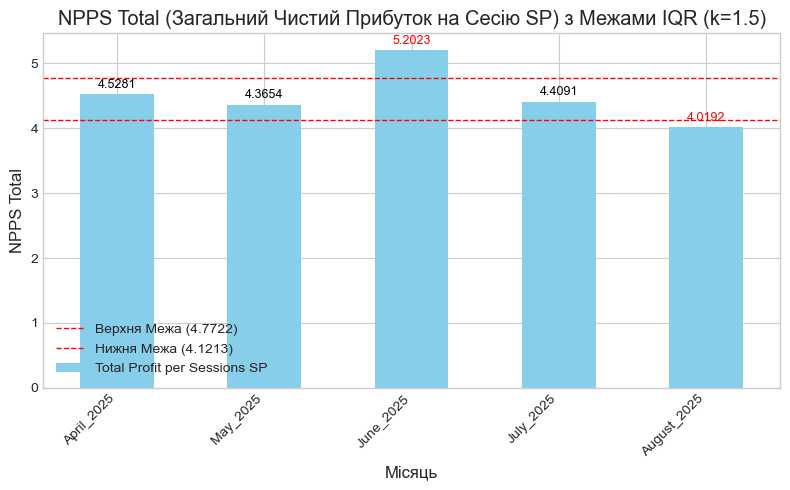


--- ОСНОВНИЙ ДАТАФРЕЙМ ДЛЯ МОДЕЛЮВАННЯ (df_model_base) ---
Цей датафрейм є основою для всіх розрахунків Методів 1-4.


In [18]:
# Припускаємо, що df_comparison_pivot та df_strategic_kpi_final визначені.

# --- 1. ПІДГОТОВКА ДАНИХ ТА РОЗРАХУНОК NPPS_TOTAL ---

try:
    # Загальний Net Profit (SP + DP)
    net_profit_sp = df_comparison_pivot.loc['Net Profit', (slice(None), 'Single Pack')].droplevel(1)
    net_profit_dp = df_comparison_pivot.loc['Net Profit', (slice(None), 'Double Pack')].droplevel(1)
    total_net_profit = net_profit_sp + net_profit_dp

    # Sessions Single Pack (початковий трафік)
    sp_sessions = df_comparison_pivot.loc['Sessions', (slice(None), 'Single Pack')].droplevel(1)
    dp_dr = df_strategic_kpi_final.loc['Double Pack DR', :]
    
except KeyError as e:
    print(f"Помилка доступу до даних. Перевірте індекси: {e}")
    raise

# Об'єднання та розрахунок NPPS_Total
df_model_filter = pd.DataFrame({
    'Total Net Profit (SP + DP)': total_net_profit,
    'Sessions Single Pack': sp_sessions,
    'Double Pack DR': dp_dr
})
df_model_filter.index.name = 'Month'
df_model_filter['Total Profit per Sessions SP'] = df_model_filter['Total Net Profit (SP + DP)'] / df_model_filter['Sessions Single Pack']


# --- 2. ФІЛЬТРАЦІЯ ЗА IQR (КОЕФІЦІЄНТ 1.5) ---

npps_series = df_model_filter['Total Profit per Sessions SP']
Q1 = npps_series.quantile(0.25)
Q3 = npps_series.quantile(0.75)
IQR = Q3 - Q1
coeff = 1.5 # Використовуємо 1.5 за останньою домовленістю
lower_bound = Q1 - coeff * IQR
upper_bound = Q3 + coeff * IQR

df_model_filter['Outlier_Detected'] = (
    (npps_series < lower_bound) | 
    (npps_series > upper_bound)
)

df_npps_clean_temp = df_model_filter[df_model_filter['Outlier_Detected'] == False].copy()


# --- 3. ВИВЕДЕННЯ РЕЗУЛЬТАТУ ФІЛЬТРАЦІЇ (ПОВНІСТЮ ВІДНОВЛЕНО) ---

print("\n--- Звіт Фільтрації Аномального Трафіку (IQR k=1.5) ---")
print("\nТаблиця значень Total Profit per Sessions SP (Рядки - показники, Стовпці - місяці):")

# Форматування таблиці: Рядки - показники, Стовпці - місяці, без градієнта
df_npps_clean_output = df_npps_clean_temp.drop(columns=['Outlier_Detected', 'Double Pack DR']).T
df_npps_clean_output.index.name = 'Metric'

styled_filter = df_npps_clean_output.style.format({
    'Total Net Profit (SP + DP)': '{:,.2f}',
    'Sessions Single Pack': '{:,.0f}',
    'Total Profit per Sessions SP': '{:.4f}',
})

display(styled_filter)

# --- ТЕКСТОВИЙ ЗВІТ ---
print("\n--- Текстовий Звіт Фільтрації ---")
excluded_data = df_model_filter[df_model_filter['Outlier_Detected'] == True]
excluded_months = excluded_data.index.tolist()
retained_months = df_npps_clean_temp.index.tolist()

print(f"Місяці, що пройшли фільтрацію та залишаються для моделювання ({len(retained_months)}): {', '.join(retained_months)}")

if not excluded_months:
    print("Місяці, що не пройшли фільтрацію: Не виявлено")
else:
    print(f"\nМісяці, що не пройшли фільтрацію ({len(excluded_months)}):")
    for month in excluded_months:
        npps_val = excluded_data.loc[month, 'Total Profit per Sessions SP']
        reason = "занадто ефективний" if npps_val > upper_bound else "занадто неефективний"
        print(f"  - {month}: {npps_val:.4f} (Викид, свідчить про {reason} трафік).")

# --- ВІЗУАЛІЗАЦІЯ (Збільшений розмір) ---
plt.figure(figsize=(8, 5)) # Збільшення розміру
plt.style.use('seaborn-v0_8-whitegrid')
npps_series.plot(kind='bar', color='skyblue')

# Додавання меж викидів
plt.axhline(upper_bound, color='red', linestyle='--', linewidth=1, label=f'Верхня Межа ({upper_bound:.4f})')
plt.axhline(lower_bound, color='red', linestyle='--', linewidth=1, label=f'Нижня Межа ({lower_bound:.4f})')

# Додавання підписів
all_months = df_model_filter.index.tolist()
for i, month in enumerate(all_months):
    npps_val = npps_series.loc[month]
    color = 'red' if df_model_filter.loc[month, 'Outlier_Detected'] else 'black'
    plt.text(i, npps_val + 0.05, f'{npps_val:.4f}', ha='center', va='bottom', fontsize=9, color=color)

plt.title('NPPS Total (Загальний Чистий Прибуток на Сесію SP) з Межами IQR (k=1.5)')
plt.ylabel('NPPS Total')
plt.xlabel('Місяць')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()


# --- 4. ФОРМУВАННЯ ОСНОВНОГО РОБОЧОГО ДАТАФРЕЙМУ ДЛЯ МЕТОДІВ (df_model_base) ---

# Включаємо всі необхідні агреговані метрики
filtered_metrics = ['Sessions', 'Units Ordered', 'Net Profit', 'Ordered Product Sales', 'Product Costs']

# Витягуємо дані з df_comparison_pivot лише для відфільтрованих місяців
df_base_filtered = df_comparison_pivot.loc[filtered_metrics, (retained_months, slice(None))]

# Створення Dataframe для DR та об'єднання
dr_cols = df_base_filtered.columns
dr_row_data = pd.DataFrame(index=['Double Pack DR'], columns=dr_cols)
for month in retained_months:
    dr_row_data.loc['Double Pack DR', (month, 'Double Pack')] = dp_dr.loc[month]

df_model_base = pd.concat([df_base_filtered, dr_row_data])


# --- НОВІ РОЗРАХУНКОВІ РЯДКИ: ASP, APC та NPPU ---

# 1. Розрахунок ASP (Average Selling Price) та APC (Average Product Cost)
asp_data = df_model_base.loc['Ordered Product Sales'] / df_model_base.loc['Units Ordered']
apc_data = df_model_base.loc['Product Costs'] / df_model_base.loc['Units Ordered']

# 2. Розрахунок NPPU (Net Profit Per Unit) - чистий дохід на одиницю
nppu_data = df_model_base.loc['Net Profit'] / df_model_base.loc['Units Ordered']

# Створення та об'єднання рядків для нових метрик
asp_row = pd.DataFrame(asp_data.values.reshape(1, -1), index=['ASP'], columns=df_model_base.columns)
apc_row = pd.DataFrame(apc_data.values.reshape(1, -1), index=['APC'], columns=df_model_base.columns)
nppu_row = pd.DataFrame(nppu_data.values.reshape(1, -1), index=['NPPU'], columns=df_model_base.columns)

df_model_base = pd.concat([df_model_base, asp_row, apc_row, nppu_row])


# Фінальне сортування та індексація
df_model_base.index.name = 'Metric'
# ОНОВЛЕНО: Новий фінальний порядок рядків
final_row_order = [
    'Sessions', 'Units Ordered', 'Ordered Product Sales', 'Product Costs', 'Net Profit', 
    'ASP', 'APC', 'NPPU', 'Double Pack DR' # Додано NPPU
]
df_model_base = df_model_base.reindex(final_row_order)

# Сортування колонок (для гарантії коректної роботи loc)
df_model_base = df_model_base.sort_index(axis=1, level=[0, 1])

print("\n--- ОСНОВНИЙ ДАТАФРЕЙМ ДЛЯ МОДЕЛЮВАННЯ (df_model_base) ---")
print("Цей датафрейм є основою для всіх розрахунків Методів 1-4.")

# Стилізація (оновлено для нових метрик ASP, APC та NPPU)
def style_model_base(df):
    format_dict = {}
    for index_name in df.index:
        if 'DR' in index_name:
            format_dict[index_name] = '{:.2%}'
        elif index_name in ['ASP', 'APC', 'NPPU']: # Додано NPPU
            format_dict[index_name] = '{:.4f}'
        else:
            format_dict[index_name] = '{:,.2f}'
    styled_df = df.style.format(format_dict)
    return styled_df

display(style_model_base(df_model_base))

<h1 style="color: #C22910;"> 🛠️ КРОК 4.2: МЕТОД 1 — Моделювання DP Conversion Rate (DP_CR)</h1>

**Оновлено:** Модель $\text{DP\_CR}$ змінена на **поліноміальну регресію 2-го порядку** для кращого відображення економічної залежності.

### 🛠️ Ключові Формули та Показники

| Назва Показника | Опис | Формула |
| :--- | :--- | :--- |
| **DP Conversion Rate** ($\text{DP\_CR}$) | **Конверсія продажів Double Pack.** Відношення кількості замовлених одиниць до кількості сесій. | $\text{DP\_CR} = \text{Units Ordered}_{\text{DP}} / \text{Sessions}_{\text{DP}}$ |
| **Поліноміальна Регресія** | Статистична модель 2-го порядку, що прогнозує $\text{DP\_CR}$ на основі $\text{DP\_DR}$ та $\text{DP\_DR}^2$. | $\text{DP\_CR} = \beta_0 + \beta_1 \cdot \text{DR} + \beta_2 \cdot \text{DR}^2$ |
| **Прибуток з Одиниці** ($\text{PPU}$) | Маржа, отримана з продажу однієї одиниці Double Pack. | $\text{PPU} = (\text{Базова Ціна} \times (1 - \text{DP\_DR})) - \text{APC}_{\text{DP}}$ |
| **Загальний Чистий Прибуток** ($\text{Net Profit}_{\text{DP}}$) | Фінальна метрика для оптимізації; загальний чистий прибуток від Double Pack. | $\text{Net Profit}_{\text{DP}} = (\text{Sessions}_{\text{DP}} \times \text{DP\_CR}) \times \text{PPU}$ |

---

### 🎯 Принцип Оптимізації та Роль Функції Прибутку

**Основна Мета:** Знайти знижку $\text{DP\_DR}$, яка максимізує **Чистий Прибуток** ($\text{Net Profit}_{\text{DP}}$).

Оптимізація проводиться шляхом пошуку максимуму функції $\text{Net Profit}_{\text{DP}}$, де:
$$\text{Net Profit}_{\text{DP}}(\text{DR}) = \text{Sessions} \times (\beta_0 + \beta_1 \cdot \text{DR} + \beta_2 \cdot \text{DR}^2) \times (\text{Price} \cdot (1 - \text{DR}) - \text{Cost})$$
Ця функція є більш складною та здатною відобразити точку, де маржа та обсяг ідеально врівноважуються.


--- Таблиця: Історичні DP_CR та DP_DR для моделювання ---


Month_Year,April_2025,July_2025,May_2025
Double Pack DR,26.9833%,16.9311%,23.2307%
DP Conversion Rate,0.4542,0.5134,0.4772



--- Текстовий Звіт Оптимізації ---
Коефіцієнт кореляції (DP_CR vs DP_DR): -0.9998
Базова Ціна (DP_Price): 42.3668
Середня Собівартість (DP_Cost): 16.4595
Середній Трафік (avg_dp_sessions): 1517 сесій DP
------------------------------
Поліноміальна Регресія (F_DP_CR, ступінь 2): DP_CR = 0.5953 + -0.4174 * DR -0.3910 * DR^2
Функція Прибутку (F_DP_Profit): NP = 1517 * CR * ((42.37 * (1-DR)) - 16.46)
------------------------------
Мінімальна Знижка, що максимізує чистий прибуток (DP_DR_Optimal): 0.0000 (0.00%)

⚠️ УВАГА: Коефіцієнт кореляції негативний. Це суперечить економічній логіці. Результат оптимізації варто сприймати обережно, оскільки модель побудована на малій кількості точок даних (3 місяці) з оберненою кореляцією.


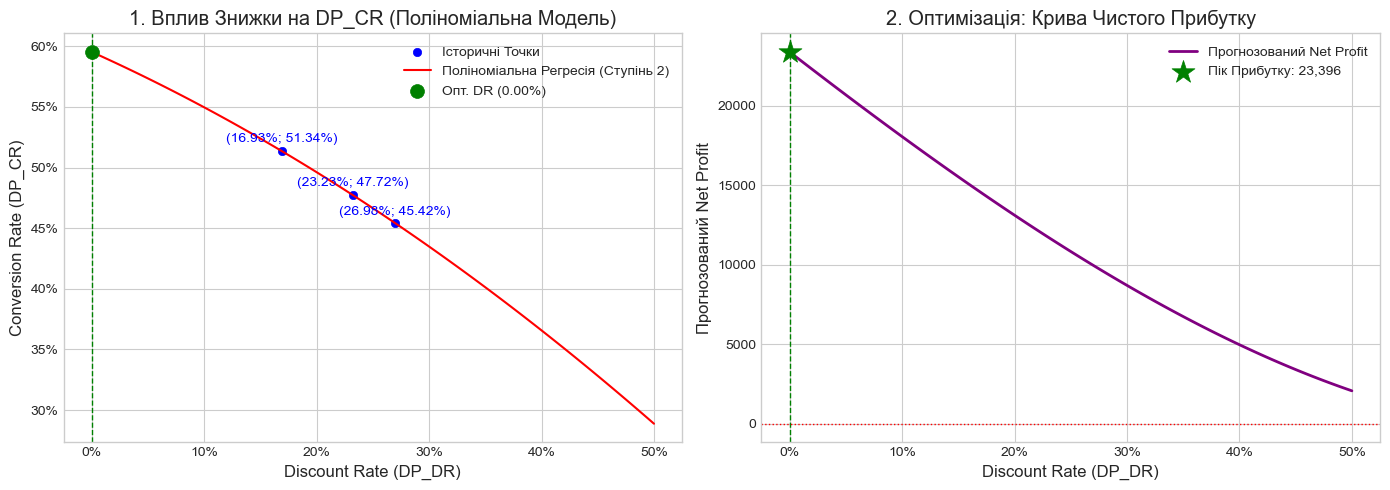

In [19]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from IPython.display import display, Markdown

# Припускаємо, що df_model_base визначений у КРОЦІ 4.1.

# --- 0. ВИЛУЧЕННЯ ДАНИХ ТА ПІДГОТОВКА ---

try:
    # Вилучення та гарантія числового типу (float)
    dp_sessions = df_model_base.loc['Sessions', (slice(None), 'Double Pack')].droplevel(1).astype(float)
    dp_units = df_model_base.loc['Units Ordered', (slice(None), 'Double Pack')].droplevel(1).astype(float)
    dp_dr = df_model_base.loc['Double Pack DR', (slice(None), 'Double Pack')].droplevel(1).astype(float)
    dp_asp = df_model_base.loc['ASP', (slice(None), 'Double Pack')].droplevel(1).astype(float)
    dp_apc = df_model_base.loc['APC', (slice(None), 'Double Pack')].droplevel(1).astype(float)
    
except Exception as e:
    print(f"Критична Помилка: Не вдалося вилучити дані з df_model_base. Переконайтеся, що КРОК 4.1 виконано коректно. Помилка: {e}")
    raise

# DP Conversion Rate (Y)
dp_cr = dp_units / dp_sessions

# Середній трафік та ціни
avg_dp_sessions = dp_sessions.mean()
dp_price_series = dp_asp / (1 - dp_dr)
DP_Price = dp_price_series.mean()
DP_Cost = dp_apc.mean()

# Робочий датафрейм для регресії
df_corr = pd.DataFrame({'DP_DR': dp_dr, 'DP_CR': dp_cr})

# РОЗРАХУНОК: Коефіцієнт кореляції
correlation_coeff = df_corr['DP_DR'].corr(df_corr['DP_CR'])


# --- 1. ПОЛІНОМІАЛЬНА РЕГРЕСІЯ (Ступінь 2) ---

X = df_corr['DP_DR'].values.reshape(-1, 1) # Знижка (DR)
Y = df_corr['DP_CR'].values                 # Конверсія (CR)

# Створюємо поліноміальні ознаки 2-го порядку
degree = 2
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)

# Навчаємо модель лінійної регресії на поліноміальних ознаках
model = LinearRegression()
model.fit(X_poly, Y)

# Коефіцієнти моделі CR = beta_0 + beta_1*DR + beta_2*DR^2
beta_0 = model.intercept_ # Вільний член
beta_1 = model.coef_[1]    # Коефіцієнт DR^1
beta_2 = model.coef_[2]    # Коефіцієнт DR^2


# --- 2. ЧИСЕЛЬНЕ ЗНАХОДЖЕННЯ ОПТИМУМУ ---

def predict_dp_cr(dr):
    """Прогнозує CR за допомогою поліноміальної моделі 2-го порядку."""
    # dr має бути одновимірним масивом (або числом)
    dr_array = np.array(dr).reshape(-1, 1)
    
    # Перетворюємо в поліноміальні ознаки (DR^0, DR^1, DR^2)
    dr_poly = poly_features.transform(dr_array)
    
    # Прогнозуємо CR (обмеження: CR не може бути < 0)
    return max(0, model.predict(dr_poly)[0])

def objective_function(dr):
    """
    Функція для розрахунку прибутку (повертає від'ємне значення для пошуку максимуму).
    NP = Sessions * CR(DR) * (Price * (1 - DR) - Cost)
    """
    cr_pred = predict_dp_cr(dr)
        
    # Прибуток з одиниці (Маржа)
    profit_per_unit = (DP_Price * (1 - dr)) - DP_Cost
    
    # Загальний чистий прибуток (за середнім трафіком)
    total_net_profit = avg_dp_sessions * cr_pred * profit_per_unit
    
    return -total_net_profit # Мінімізуємо від'ємний прибуток

# Діапазон DR для оптимізації (0% до 50%)
dr_bounds = [(0.0, 0.50)] 

# Початкове значення для пошуку (середнє значення знижки)
initial_discount = np.mean(X)

# Запуск чисельної оптимізації
optimization_result = minimize(
    objective_function, 
    initial_discount, 
    method='L-BFGS-B', 
    bounds=dr_bounds
)

# Витягуємо оптимальний відсоток знижки та відповідний максимальний прибуток
optimal_dr = optimization_result.x[0]
max_profit = -optimization_result.fun 
optimal_cr = predict_dp_cr(optimal_dr)


# --- 3. ВИВЕДЕННЯ РЕЗУЛЬТАТІВ ---

# 3.1. Таблиця DP_CR та DP_DR по місяцям
print("\n--- Таблиця: Історичні DP_CR та DP_DR для моделювання ---")
df_method1_table = df_corr.T
df_method1_table.index = ['Double Pack DR', 'DP Conversion Rate']

# Використовуємо pd.Styler для форматування
styled_cr = df_method1_table.style.format(
    lambda v: '{:.4%}'.format(v) if v in df_method1_table.loc['Double Pack DR'].values else '{:.4f}'.format(v)
).set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]}])
display(styled_cr)


# 3.2. Текстовий Звіт
print("\n--- Текстовий Звіт Оптимізації ---")

# Форматування функції CR для поліноміального виводу
if beta_2 < 0:
    F_DP_CR_str = f"DP_CR = {beta_0:.4f} + {beta_1:.4f} * DR {beta_2:.4f} * DR^2"
else:
    F_DP_CR_str = f"DP_CR = {beta_0:.4f} + {beta_1:.4f} * DR + {beta_2:.4f} * DR^2"

# Форматування функції прибутку (Маржа)
F_DP_Profit_str = f"NP = {avg_dp_sessions:.0f} * CR * (({DP_Price:.2f} * (1-DR)) - {DP_Cost:.2f})"

print(f"Коефіцієнт кореляції (DP_CR vs DP_DR): {correlation_coeff:.4f}")
print(f"Базова Ціна (DP_Price): {DP_Price:.4f}")
print(f"Середня Собівартість (DP_Cost): {DP_Cost:.4f}")
print(f"Середній Трафік (avg_dp_sessions): {avg_dp_sessions:.0f} сесій DP")
print("-" * 30)
print(f"Поліноміальна Регресія (F_DP_CR, ступінь 2): {F_DP_CR_str}")
print(f"Функція Прибутку (F_DP_Profit): {F_DP_Profit_str}")
print("-" * 30)
print(f"Мінімальна Знижка, що максимізує чистий прибуток (DP_DR_Optimal): {optimal_dr:.4f} ({optimal_dr:.2%})")

# КОМЕНТАР ПРО СТАТИСТИЧНУ НЕНАДІЙНІСТЬ
if correlation_coeff < 0:
    print("\n⚠️ УВАГА: Коефіцієнт кореляції негативний. Це суперечить економічній логіці. Результат оптимізації варто сприймати обережно, оскільки модель побудована на малій кількості точок даних (3 місяці) з оберненою кореляцією.")


# 3.3. Візуалізація: Два Графіки

# Створюємо діапазон знижок для побудови плавної кривої
X_range = np.linspace(0.0, 0.50, 100).reshape(-1, 1) 
X_range_poly = poly_features.transform(X_range)
y_pred_cr = model.predict(X_range_poly)
y_pred_cr = np.maximum(0, y_pred_cr) # Обмеження: CR не може бути < 0

# Прогнозований Прибуток для графіка
y_pred_profit = -np.array([objective_function(dr[0]) for dr in X_range]) 

plt.figure(figsize=(14, 5))
plt.style.use('seaborn-v0_8-whitegrid')

# --- Графік 1: Поліноміальна Регресія DP_CR vs DR ---
plt.subplot(1, 2, 1)
plt.scatter(X, Y, color='blue', label='Історичні Точки')
plt.plot(X_range, y_pred_cr, color='red', linestyle='-', label=f'Поліноміальна Регресія (Ступінь {degree})')

# Додавання підписів точок у форматі (X%; Y%) та збільшення шрифту
for i in range(len(X)):
    # Зміна підпису на (X%; Y%)
    label_text = f"({X[i][0]:.2%}; {Y[i]:.2%})"
    plt.text(X[i][0], Y[i] * 1.015, label_text, fontsize=10, ha='center', color='blue')

# Оптимальна точка
plt.scatter(optimal_dr, optimal_cr, color='green', marker='o', s=100, zorder=5, label=f'Опт. DR ({optimal_dr:.2%})')
plt.axvline(optimal_dr, color='green', linestyle='--', linewidth=1)

plt.title(f'1. Вплив Знижки на DP_CR (Поліноміальна Модель)')
plt.xlabel('Discount Rate (DP_DR)')
plt.ylabel('Conversion Rate (DP_CR)')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.legend()


# --- Графік 2: Крива Прибутку vs DR (Пошук Оптимуму) ---
plt.subplot(1, 2, 2)
plt.plot(X_range, y_pred_profit, color='purple', linewidth=2, label='Прогнозований Net Profit')

# Максимальна точка прибутку
plt.scatter(optimal_dr, max_profit, color='green', marker='*', s=300, zorder=5, label=f'Пік Прибутку: {max_profit:,.0f}')
plt.axvline(optimal_dr, color='green', linestyle='--', linewidth=1)
plt.axhline(0, color='red', linestyle=':', linewidth=1) # Точка Беззбитковості (Profit = 0)

plt.title('2. Оптимізація: Крива Чистого Прибутку')
plt.xlabel('Discount Rate (DP_DR)')
plt.ylabel('Прогнозований Net Profit') 
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.ticklabel_format(style='plain', axis='y')
plt.legend()

plt.tight_layout()
plt.show()